# Predicting European Wheat Futures Returns from Satellite-Derived Agricultural Data: A Test of Market Efficiency

**MA429 — Algorithms in Machine Learning**

---

## Abstract

We investigate whether publicly available satellite-derived agricultural data from the CY-Bench benchmark (Paudel et al., 2025) predicts Euronext Milling Wheat N2 futures returns. Following the practical methodology prescribed by Goodfellow, Bengio, and Courville (2016, Chapter 11), we systematically establish performance metrics, build default baselines, diagnose underfitting versus overfitting through train-test gap analysis, augment the feature space with cross-commodity market data, tune hyperparameters via random search (Bergstra and Bengio, 2012), and escalate model complexity from linear baselines through tree ensembles to deep feedforward neural networks with proper train-validation-test separation.

We compare two spatial strategies — agro-climatic clustering (6 clusters from 515 regions) and per-region modelling (515 individual models) — and evaluate both standard return prediction and tail event detection. All models produce negative out-of-sample R-squared for standard return prediction. Training R-squared itself is remarkably low (0.02 to 0.15 for regularised models), indicating a data quality issue per Goodfellow et al. §11.3 rather than a modelling failure: daily wheat returns are dominated by macro and speculative factors that no agricultural feature can capture. This is consistent with the semi-strong Efficient Market Hypothesis (Fama, 1970).

When the task is reformulated as tail event detection — predicting returns exceeding two rolling standard deviations — agricultural features outperform market-only features. The best tree ensemble achieves Gate AUC of 0.666 after hyperparameter tuning, the hurdle model achieves per-year AUC ranging from 0.480 (2022, Ukraine war) to 0.799 (2023, agricultural stress year), and directional accuracy on tail days reaches 60 per cent for three-sigma events. Deep neural networks with proper validation do not outperform regularised tree ensembles on this tabular dataset, consistent with Grinsztajn, Oyallon, and Varoquaux (2022).

**Keywords:** market efficiency, wheat futures, satellite data, CY-Bench, tail risk, machine learning, neural networks, walk-forward validation

---

## 1. Methodological Framework

This notebook implements the practical design process prescribed by Goodfellow, Bengio, and Courville (2016, Chapter 11, pp. 416-425). The methodology consists of four iterative steps that we apply sequentially, documenting each diagnostic decision.

The first step concerns **performance metrics** (§11.1). Goodfellow et al. write that "determining your goals, in terms of which error metric to use, is a necessary first step because your error metric will guide all your future actions" (p. 417). For rare-event detection, they warn that accuracy can be trivially maximised and recommend precision-recall or AUC instead (p. 418). We define separate metric suites for standard return prediction and tail event detection.

The second step establishes **default baseline models** (§11.2). The chapter advises beginning simply: "if your problem has a chance of being solved by just choosing a few linear weights correctly, you may want to begin with a simple statistical model" (p. 420). Model family should follow data structure — feedforward networks for fixed-size vectors, convolutional for spatial topology, recurrent for sequences (p. 420). We begin with Ridge regression and escalate through tree ensembles to deep feedforward networks with ReLU activations, batch normalisation, dropout, and early stopping — all defaults recommended by Goodfellow et al. (p. 420).

The third step asks **whether to gather more data** (§11.3). The diagnostic sequence is: check training error first — if high, increase capacity; if training is good but test is poor, regularise or gather more data; if both are poor despite large capacity, "the problem might be the quality of the training data" (p. 421). This diagnostic drives our decision to (a) augment features with market data and (b) reformulate the task as tail event detection.

The fourth step addresses **hyperparameter selection** (§11.4). Goodfellow et al. note that "the learning rate is perhaps the most important hyperparameter" (p. 424) and recommend understanding the U-shaped relationship between capacity and generalisation error. Following Bergstra and Bengio (2012), we use random search over hyperparameter distributions.

---

## 2. Performance Metrics (Goodfellow et al. §11.1)

### 2.1 The Bayes Error for Financial Returns

Goodfellow et al. observe that "the Bayes error defines the minimum error rate that you can hope to achieve, even if you have infinite training data" (p. 417). For daily wheat futures returns, the Bayes error is extremely high because returns are dominated by unpredictable noise. Gu, Kelly, and Xiu (2020) found monthly out-of-sample R-squared of only 0.4% even with 94 stock characteristics and panel data spanning thousands of firms — our single-asset task is strictly harder.

### 2.2 Standard Return Prediction Metrics

We report out-of-sample R-squared ($R^2_{OOS} = 1 - SS_{res}/SS_{tot}$), directional accuracy, and RMSE. Negative R-squared indicates the model underperforms the unconditional mean — a diagnostic signal, not a failure. We also report **training R-squared** to diagnose underfitting versus overfitting per Goodfellow §11.3.

### 2.3 Tail Event Detection Metrics

Goodfellow et al. address rare events: "suppose that only one in every million people has this disease. We can easily achieve 99.9999 percent accuracy... Clearly, accuracy is a poor way to characterize the performance of such a system" (p. 418). Our tail events occur on ~5% of days. We use Gate AUC (Fawcett, 2006), conditional directional accuracy on tail days (the tradeable metric), and separation ratio. We omit R-squared for the filtered target because 95% of values are zero.

---

## 3. Data

### 3.1 Price Data and Agricultural Features

We use Euronext Milling Wheat N2 roll-adjusted daily prices (2003-2023, 5,389 trading days) and CY-Bench sub-national agricultural indicators for 515 regions across France (97), Germany (401), and Poland (17). Features include weather (AgERA5), soil moisture (GLDAS), vegetation indices (MODIS NDVI, JRC fPAR), engineered into 76 features per region capturing rolling means, growing degree days, drought indices, NDVI anomalies, and crop-phase stress indicators.

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import warnings
from datetime import timedelta

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All imports successful.")

All imports successful.


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
FUTURES_PATH = "./cy-bench/CA1 Commodity Historical Data v2.xlsx"
CYBENCH_DATA_DIR = "../data/raw/cybench/cybench-data/wheat/"

FORECAST_HORIZON = 5   # 5 trading days (1 week) forward return
AG_LAG_DAYS = 0        # No artificial lag: futures traders react in real time

# ============================================================
# Load futures data
# ============================================================
futures_raw = pd.read_excel(FUTURES_PATH, na_values=['#N/A N/A', '#N/A', 'N/A'])
futures_raw = futures_raw.drop(columns=[c for c in futures_raw.columns 
                                         if 'Unnamed' in str(c) or 'Setting' in str(c)],
                                errors='ignore')
print(f"Raw futures data shape: {futures_raw.shape}")
futures_raw.head()

Raw futures data shape: (6968, 16)


,Date,PX_LAST,PX_BID,OPEN_INT,PX_OPEN,PX_HIGH,PX_LOW,PX_VOLUME,PX_LAST_ADJ,PX_BID_ADJ,OPEN_INT_ADJ,PX_OPEN_ADJ,PX_HIGH_ADJ,PX_LOW_ADJ,PX_VOLUME_ADJ,ROLL
0,2026-03-02,201.25,201.00,NaN,203.75,204.25,200.50,85071.0,201.25,201.00,NaN,203.75,204.25,200.50,85071.0,1.001244
1,2026-02-27,197.50,193.75,9694.0,193.50,197.75,193.50,12930.0,201.50,197.67,9694.0,197.42,201.76,197.42,12930.0,0.999140
2,2026-02-26,193.25,192.00,15198.0,193.25,194.50,192.25,12908.0,197.16,195.89,15198.0,197.16,198.44,196.14,12908.0,0.986523
3,2026-02-25,193.00,192.50,19460.0,195.50,195.75,192.50,15145.0,196.91,196.40,19460.0,199.46,199.71,196.40,15145.0,0.982688
4,2026-02-24,195.25,195.00,25540.0,195.50,197.25,195.00,20632.0,199.20,198.95,25540.0,199.46,201.24,198.95,20632.0,0.981402


In [3]:
# Parse and clean futures data
futures = futures_raw.copy()
futures['Date'] = pd.to_datetime(futures['Date'], format='%m/%d/%Y')
futures = futures.sort_values('Date').reset_index(drop=True)

# Use adjusted columns
futures['Price'] = futures['PX_LAST_ADJ']
futures['Open'] = futures['PX_OPEN_ADJ']
futures['High'] = futures['PX_HIGH_ADJ']
futures['Low'] = futures['PX_LOW_ADJ']
futures['Volume'] = futures['PX_VOLUME_ADJ']

# Filter to 2003-2023
futures = futures[
    (futures['Date'] >= '2002-12-31') & (futures['Date'] <= '2023-12-31')
].copy()

futures = futures[['Date', 'Price', 'Open', 'High', 'Low', 'Volume']]
futures['Volume'] = futures['Volume'].ffill()
futures = futures.dropna(subset=['Price']).reset_index(drop=True)

print(f"Futures data: {futures.shape[0]} trading days from "
      f"{futures['Date'].min().date()} to {futures['Date'].max().date()}")
futures.head()

Futures data: 5389 trading days from 2002-12-31 to 2023-12-29


,Date,Price,Open,High,Low,Volume
0,2002-12-31,76.15,76.15,76.15,76.15,2.0
1,2003-01-02,76.15,76.15,76.15,76.15,38.0
2,2003-01-03,76.15,76.15,76.15,76.15,4.0
3,2003-01-06,76.15,76.15,76.15,76.15,5.0
4,2003-01-07,75.31,75.98,75.98,75.31,97.0


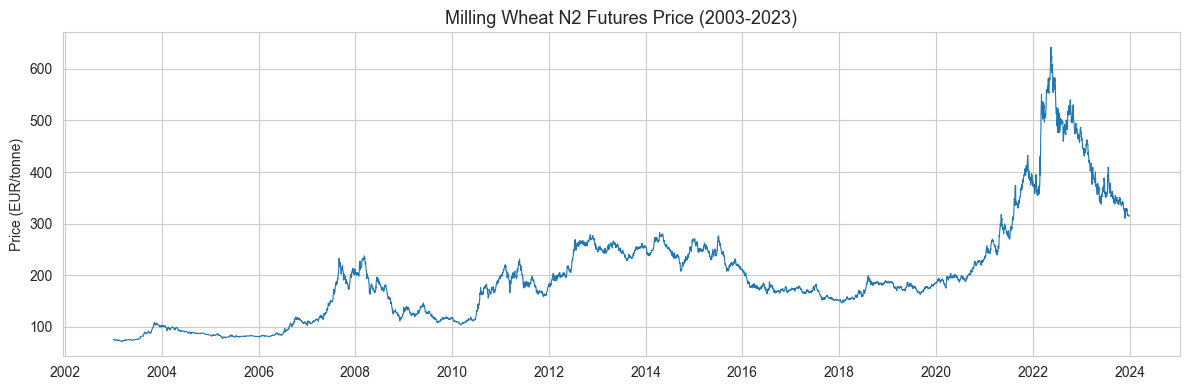

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(futures['Date'], futures['Price'], linewidth=0.8)
ax.set_title('Milling Wheat N2 Futures Price (2003-2023)', fontsize=13)
ax.set_ylabel('Price (EUR/tonne)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Target: continuous 5-day forward return (regression)
# ============================================================
futures['Fwd_Return'] = futures['Price'].shift(-FORECAST_HORIZON) / futures['Price'] - 1

# ============================================================
# MINIMAL price features: returns + volume only
#
# We deliberately strip price features to the bare minimum.
# The goal is to isolate whether AGRICULTURAL data from
# CY-Bench adds predictive signal, not to build the best
# possible price-based model. If we included RSI, SMAs,
# Bollinger bands etc., any lift from ag features could be
# confounded with price feature interactions.
#
# We keep only:
#   - ret_5d: 1-week momentum (same horizon as target)
#   - ret_20d: 1-month momentum (medium-term trend)
#   - vol_sma_ratio: relative volume (liquidity/attention)
#
# These 3 features form a minimal "market state" control.
# ============================================================

futures['ret_5d'] = futures['Price'].pct_change(5)
futures['ret_20d'] = futures['Price'].pct_change(20)
futures['vol_sma_ratio'] = futures['Volume'] / futures['Volume'].rolling(20).mean()

price_feature_cols = ['ret_5d', 'ret_20d', 'vol_sma_ratio']
print(f"Price features ({len(price_feature_cols)}): {price_feature_cols}")

Price features (3): ['ret_5d', 'ret_20d', 'vol_sma_ratio']


In [6]:
# ============================================================
# Generic CY-Bench loader for any country
# ============================================================

def load_cybench_csv(directory, pattern):
    matches = glob.glob(os.path.join(directory, pattern))
    if not matches:
        return None
    df = pd.read_csv(matches[0])
    return df

def load_country_data(country_code, cybench_dir):
    """
    Load all CY-Bench CSVs for a given country code.
    Returns dict of DataFrames keyed by data type.
    """
    possible = [
        os.path.join(cybench_dir, country_code),
        os.path.join(cybench_dir, 'EU'),
        cybench_dir,
    ]
    data_dir = None
    for p in possible:
        if os.path.isdir(p):
            pattern = f'meteo_wheat_{country_code}.csv'
            if glob.glob(os.path.join(p, pattern)):
                data_dir = p
                break

    if data_dir is None:
        print(f"  {country_code}: Data not found, skipping.")
        return None

    print(f"  {country_code}: Loading from {data_dir}")
    datasets = {}
    for var, pat in [('meteo', f'meteo_wheat_{country_code}.csv'),
                     ('soil_moisture', f'soil_moisture_wheat_{country_code}.csv'),
                     ('ndvi', f'ndvi_wheat_{country_code}.csv'),
                     ('fpar', f'fpar_wheat_{country_code}.csv')]:
        df = load_cybench_csv(data_dir, pat)
        if df is not None:
            # Filter to country regions
            if 'adm_id' in df.columns:
                df = df[df['adm_id'].astype(str).str.startswith(country_code)].copy()
            datasets[var] = df
            print(f"    {var}: {df.shape}, {df['adm_id'].nunique()} regions")

    # Load yield data for production weights
    yield_df = load_cybench_csv(data_dir, f'yield_wheat_{country_code}.csv')
    if yield_df is not None and 'adm_id' in yield_df.columns:
        yield_df = yield_df[yield_df['adm_id'].astype(str).str.startswith(country_code)].copy()
        datasets['yield'] = yield_df
        print(f"    yield: {yield_df.shape}, {yield_df['adm_id'].nunique()} regions")

    return datasets

# Load all three countries
print("Loading CY-Bench agricultural data\n")
country_data = {}

# DK not included because yield data starts in 2006
# countries = ['FR', 'DE', 'PL', 'RO', 'BG', 'LT', 'CZ', 'ES']
# countries = ['FR', 'DE', 'PL', 'RO', 'BG']
countries = ['FR', 'DE', 'PL']

for country in countries:
    data = load_country_data(country, CYBENCH_DATA_DIR)
    if data is not None:
        country_data[country] = data
    print()

print(f"Countries loaded: {list(country_data.keys())}")
for country, data in country_data.items():
    n_regions = set()
    for k, df in data.items():
        if 'adm_id' in df.columns:
            n_regions.update(df['adm_id'].unique())
    print(f"  {country}: {len(n_regions)} unique regions, data types: {list(data.keys())}")

Loading CY-Bench agricultural data

  FR: Loading from ../data/raw/cybench/cybench-data/wheat/FR
    meteo: (814800, 11), 97 regions
    soil_moisture: (740886, 5), 97 regions
    ndvi: (97951, 4), 97 regions
    fpar: (80316, 4), 97 regions
    yield: (2571, 7), 95 regions

  DE: Loading from ../data/raw/cybench/cybench-data/wheat/DE
    meteo: (3368400, 11), 401 regions
    soil_moisture: (3055200, 5), 400 regions
    ndvi: (350540, 4), 401 regions
    fpar: (332028, 4), 401 regions
    yield: (15233, 12), 397 regions

  PL: Loading from ../data/raw/cybench/cybench-data/wheat/PL
    meteo: (142800, 11), 17 regions
    soil_moisture: (129846, 5), 17 regions
    ndvi: (16115, 4), 17 regions
    fpar: (14076, 4), 17 regions
    yield: (301, 7), 17 regions

Countries loaded: ['FR', 'DE', 'PL']
  FR: 98 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']
  DE: 401 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']
  PL: 17 unique re

The following cells execute the computationally expensive data loading, production weight calculation, and feature engineering pipeline. Outputs are preserved from previous execution.

In [7]:
# ============================================================
# Step 4a: Build production weights per region
#
# Production weights serve TWO purposes:
#   1. Aggregating per-region predictions to EU level
#      (Paudel et al. 2022, Section 2.5.3)
#   2. Informing which regions matter economically
#
# We use PREVIOUS year's production to avoid look-ahead bias.
#
# HANDLING INCOMPLETE DATA (Germany):
#   Germany's CY-Bench data has:
#     - yield:        available every year
#     - harvest_area: available only every ~4 years (census)
#     - production:   entirely NaN
#   France/Poland have all three columns filled.
#
#   Solution (following user specification):
#     1. Forward-fill harvest_area within each region
#        (area changes slowly between censuses)
#     2. Compute production = yield * harvest_area
#   This is standard practice: Eurostat publishes area data
#   less frequently than yield, and interpolation/carry-forward
#   is the norm in operational systems (Cerrani & López Lozano,
#   2017).
#
# HANDLING SHORT TIME SERIES:
#   Some regions stop reporting before 2023 (e.g., France stops
#   at 2020, some German regions earlier). We use the most
#   recent available production as fallback.
# ============================================================

production_weights = {}  # {adm_id: {year: production_tonnes}}

for cc, data in country_data.items():
    if 'yield' not in data:
        continue
    ydf = data['yield'].copy()

    # Ensure columns exist
    if 'yield' not in ydf.columns:
        continue

    # --- Handle missing harvest_area and production ---
    # Check which area column exists (FR uses 'harvest_area', DE also)
    area_col = None
    for candidate in ['harvest_area', 'planted_area']:
        if candidate in ydf.columns:
            area_col = candidate
            break

    if area_col is not None:
        # Forward-fill harvest_area within each region
        # (area changes slowly; census every ~4 years for DE)
        ydf = ydf.sort_values(['adm_id', 'harvest_year'])
        ydf[area_col] = ydf.groupby('adm_id')[area_col].ffill()
        # Also backward-fill to cover years before first census
        ydf[area_col] = ydf.groupby('adm_id')[area_col].bfill()

    # Compute production where missing
    if 'production' not in ydf.columns:
        ydf['production'] = np.nan

    missing_prod = ydf['production'].isna()
    if missing_prod.any() and area_col is not None:
        ydf.loc[missing_prod, 'production'] = (
            ydf.loc[missing_prod, 'yield'] * ydf.loc[missing_prod, area_col]
        )
        n_filled = missing_prod.sum() - ydf['production'].isna().sum()
        print(f"  {cc}: Filled {n_filled} missing production values "
              f"(yield * forward-filled {area_col})")

    # Remaining NaN in production (no area data at all)
    still_missing = ydf['production'].isna().sum()
    if still_missing > 0:
        print(f"  {cc}: {still_missing} rows still missing production "
              f"(no area data available)")

    # Build the weights dictionary
    for _, row in ydf.iterrows():
        adm = row['adm_id']
        yr = row['harvest_year']
        prod = row['production']
        if pd.notna(prod) and prod > 0:
            if adm not in production_weights:
                production_weights[adm] = {}
            production_weights[adm][yr] = prod

    n_regions = len([r for r in production_weights if r.startswith(cc)])
    print(f"  {cc}: {n_regions} regions with production weights")

print(f"\nTotal regions with production weights: {len(production_weights)}")
for cc in country_data:
    cc_regions = [r for r in production_weights if r.startswith(cc)]
    if cc_regions:
        # Show year coverage
        all_years = set()
        for r in cc_regions:
            all_years.update(production_weights[r].keys())
        print(f"  {cc}: {len(cc_regions)} regions, "
              f"years {min(all_years)}-{max(all_years)}")

# Helper: get production weight for a region in a given year
# Uses previous year's production (lag 1 year to avoid look-ahead)
def get_production_weight(adm_id, year):
    if adm_id not in production_weights:
        return 0.0
    prev_year = year - 1
    if prev_year in production_weights[adm_id]:
        return production_weights[adm_id][prev_year]
    # Fallback: use nearest earlier available year
    available = sorted(production_weights[adm_id].keys())
    earlier = [y for y in available if y < year]
    if earlier:
        return production_weights[adm_id][earlier[-1]]
    # Last resort: use earliest available
    if available:
        return production_weights[adm_id][available[0]]
    return 0.0

  FR: 95 regions with production weights
  DE: Filled 15223 missing production values (yield * forward-filled harvest_area)
  DE: 10 rows still missing production (no area data available)
  DE: 396 regions with production weights
  PL: 17 regions with production weights

Total regions with production weights: 508
  FR: 95 regions, years 1989-2020
  DE: 396 regions, years 1979-2021
  PL: 17 regions, years 2003-2020


In [8]:
# ============================================================
# Step 4b: Process time-series data PER REGION
#
# For each region, we:
#   1. Parse dates
#   2. Combine all data types (meteo, soil, ndvi, fpar)
#   3. Forward-fill to daily frequency
#   4. Store as {adm_id: DataFrame}
#
# NO cross-regional aggregation at this stage.
# ============================================================

def process_region_timeseries(df, name):
    """Parse dates and identify variable columns."""
    if df is None or df.empty:
        return None
    df = df.copy()
    meta_cols = {'adm_id', 'crop_name', 'country_code', 'date',
                 'harvest_year', 'yield', 'harvest_area', 'production',
                 'sos', 'eos', 'crop_area', 'crop_area_percentage',
                 'region_area', 'geometry'}
    var_cols = [c for c in df.columns if c not in meta_cols]
    if 'date' not in df.columns:
        return None
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['date'])
    for c in var_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df[['adm_id', 'date'] + var_cols], var_cols

def build_region_daily(datasets, country_code):
    """
    Build per-region daily DataFrames from CY-Bench data.
    Returns dict: {adm_id: DataFrame with date + variable columns}
    """
    # Process each data type
    processed = {}
    for dtype in ['meteo', 'soil_moisture', 'ndvi', 'fpar']:
        if dtype not in datasets:
            continue
        result = process_region_timeseries(datasets[dtype], f"{country_code}_{dtype}")
        if result is not None:
            df, var_cols = result
            # Prefix variable names with dtype
            rename = {c: f'{dtype}_{c}' for c in var_cols}
            df = df.rename(columns=rename)
            processed[dtype] = df

    if not processed:
        return {}

    # Get all regions across data types
    all_regions = set()
    for df in processed.values():
        all_regions.update(df['adm_id'].unique())

    # Build per-region combined DataFrames
    region_dfs = {}
    for region in sorted(all_regions):
        dfs_for_region = []
        for dtype, df in processed.items():
            rdf = df[df['adm_id'] == region].drop(columns=['adm_id']).copy()
            if len(rdf) == 0:
                continue
            rdf = rdf.sort_values('date')
            dfs_for_region.append(rdf)

        if not dfs_for_region:
            continue

        # Merge all data types on date
        combined = dfs_for_region[0]
        for df in dfs_for_region[1:]:
            combined = combined.merge(df, on='date', how='outer')
        combined = combined.sort_values('date')

        # Expand to daily with LOCF
        full_dates = pd.date_range(combined['date'].min(),
                                    combined['date'].max(), freq='D')
        combined = combined.set_index('date').reindex(full_dates).ffill()
        combined = combined.reset_index().rename(columns={'index': 'date'})

        region_dfs[region] = combined

    return region_dfs


# Build per-region daily data for all countries
print("Building per-region daily datasets...\n")
all_region_dfs = {}  # {adm_id: DataFrame}

for cc, data in country_data.items():
    region_dfs = build_region_daily(data, cc)
    all_region_dfs.update(region_dfs)
    print(f"  {cc}: {len(region_dfs)} regions processed")
    if region_dfs:
        sample_region = list(region_dfs.keys())[0]
        sample_df = region_dfs[sample_region]
        n_feats = len([c for c in sample_df.columns if c != 'date'])
        print(f"    Sample region {sample_region}: {sample_df.shape[0]} days, "
              f"{n_feats} features")
        print(f"    Date range: {sample_df['date'].min().date()} to "
              f"{sample_df['date'].max().date()}")

print(f"\nTotal regions across all countries: {len(all_region_dfs)}")

Building per-region daily datasets...

  FR: 97 regions processed
    Sample region FR102: 8400 days, 12 features
    Date range: 2001-01-01 to 2023-12-31
  DE: 401 regions processed
    Sample region DE111: 8400 days, 12 features
    Date range: 2001-01-01 to 2023-12-31
  PL: 17 regions processed
    Sample region PL21: 8400 days, 12 features
    Date range: 2001-01-01 to 2023-12-31

Total regions across all countries: 515


In [9]:
# ============================================================
# Load pre-generated per-region daily CSVs
#
# Skips: CY-Bench loading, parsing, daily expansion, saving
# Requires: the region_daily_data/ folder from a previous run
# Only loads regions from countries in the countries list.
# ============================================================

REGION_DATA_DIR = "region_daily_data"

# --- Load region index ---
index_path = os.path.join(REGION_DATA_DIR, "_region_index.csv")
region_index = pd.read_csv(index_path)
print(f"Found {len(region_index)} total regions in '{REGION_DATA_DIR}/'")

# --- Filter to countries list ---
region_index = region_index[region_index['country'].isin(countries)]
print(f"After filtering to {countries}: {len(region_index)} regions")

# --- Load region CSVs into all_region_dfs ---
all_region_dfs = {}
for _, row in region_index.iterrows():
    adm_id = row['adm_id']
    path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
    df = pd.read_csv(path, parse_dates=['date'])
    all_region_dfs[adm_id] = df

print(f"Loaded {len(all_region_dfs)} regions")
print(f"countries: {region_index.groupby('country')['adm_id'].count().to_dict()}")

Found 515 total regions in 'region_daily_data/'
After filtering to ['FR', 'DE', 'PL']: 515 regions
Loaded 515 regions
countries: {'DE': 401, 'FR': 97, 'PL': 17}


In [10]:
# ============================================================
# Per-region feature engineering
#
# For each region's daily DataFrame, we compute:
#   1. Rolling means and cumulative sums (30d, 60d windows)
#   2. Threshold-based stress indicators (CY-Bench: cold/hot/dry days)
#   3. NDVI/fPAR anomalies (relative to expanding DOY climatology)
#   4. Phenological phase indicators (based on month)
#   5. Cross-variable interactions (VPD stress, DTR)
#
# CY-Bench Section 2.2.3: "Following expert recommendations we create
# monthly averages... cumulative growing degree days, cumulative
# precipitation, cumulative fPAR and cumulative NDVI... number of days
# in which tmin < 0 ('cold days'), tmax > 35 ('hot days'), prec < 1mm
# ('dry days')."
# ============================================================

def engineer_region_features(df):
    """
    Apply feature engineering to a single region's daily DataFrame.
    Input: DataFrame with 'date' column and raw CY-Bench variables.
    Output: DataFrame with original + engineered features.
    """
    df = df.copy().sort_values('date').set_index('date')
    month = df.index.month

    # ============================================================
    # A. PHENOLOGICAL PHASE INDICATORS
    # Binary flags for which crop phase we're in.
    # French winter wheat phenology:
    #   Sowing → Emergence: Oct-Nov
    #   Dormancy / Vernalisation: Dec-Feb
    #   Stem elongation: Mar-Apr
    #   Heading / Flowering: May
    #   Grain filling: Jun-Jul
    # ============================================================
    df['in_growing_season'] = ((month >= 10) | (month <= 7)).astype(float)
    df['phase_dormant'] = ((month >= 12) | (month <= 2)).astype(float)
    df['phase_stem_elong'] = ((month >= 3) & (month <= 4)).astype(float)
    df['phase_flowering'] = (month == 5).astype(float)
    df['phase_grain_fill'] = ((month >= 6) & (month <= 7)).astype(float)

    # ============================================================
    # B. PHASE-CONDITIONAL STRESS FEATURES
    # These only accumulate stress during vulnerable windows.
    # ============================================================

    # --- Vernalisation frost stress (Dec-Feb): days < -10°C ---
    if 'meteo_tmin' in df.columns:
        frost_mask = df['phase_dormant'] * (df['meteo_tmin'] < -10).astype(float)
        df['winterkill_risk_30d'] = frost_mask.rolling(30, min_periods=5).sum()
        df['winterkill_risk_60d'] = frost_mask.rolling(60, min_periods=5).sum()
        # Milder frost days (< -5°C) during dormancy
        mild_frost = df['phase_dormant'] * (df['meteo_tmin'] < -5).astype(float)
        df['frost_days_dormant_60d'] = mild_frost.rolling(60, min_periods=5).sum()

    # --- Spring heat shock (Mar-May): days > 25°C ---
    if 'meteo_tmax' in df.columns:
        spring_heat = ((month >= 3) & (month <= 5)).astype(float) * (df['meteo_tmax'] > 25).astype(float)
        df['spring_heat_days_30d'] = spring_heat.rolling(30, min_periods=5).sum()
        df['spring_heat_days_60d'] = spring_heat.rolling(60, min_periods=5).sum()

    # --- Grain-fill heat stress (May-Jul): days > 30°C ---
    # Schlenker & Roberts (2009): nonlinear temperature effects
    # indicate severe damages to US crop yields
    if 'meteo_tmax' in df.columns:
        gf_heat = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] > 30).astype(float)
        df['grainfill_heat_days_30d'] = gf_heat.rolling(30, min_periods=5).sum()
        # Cumulative excess heat above 30°C during grain fill
        gf_excess = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] - 30).clip(lower=0)
        df['grainfill_excess_heat_30d'] = gf_excess.rolling(30, min_periods=5).sum()

    # --- CY-Bench threshold indicators (Paudel et al. 2025, §2.2.3) ---
    # "number of days tmin < 0°C ('cold days'), tmax > 35°C ('hot days'),
    #  prec < 1mm ('dry days')"
    if 'meteo_tmin' in df.columns:
        df['cold_days_30d'] = (df['meteo_tmin'] < 0).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_tmax' in df.columns:
        df['hot_days_30d'] = (df['meteo_tmax'] > 35).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_prec' in df.columns:
        df['dry_days_30d'] = (df['meteo_prec'] < 1).astype(float).rolling(30, min_periods=5).sum()

    # --- Flowering drought (Apr-Jun): cumul water deficit ---
    if 'meteo_cwb' in df.columns:
        flower_cwb = df['meteo_cwb'].copy()
        flower_cwb[~((month >= 4) & (month <= 6))] = 0
        df['flowering_drought_60d'] = flower_cwb.rolling(60, min_periods=5).sum()
        df['flowering_drought_90d'] = flower_cwb.rolling(90, min_periods=5).sum()

    # ============================================================
    # C. NDVI ANOMALY - "crop health surprise"
    # How does current NDVI compare to what's normal for this
    # time of year? Low NDVI in Jan = normal (dormant).
    # Low NDVI in May = disaster. We compute the anomaly
    # relative to the historical day-of-year mean.
    # Expanding climatology avoids future leakage.
    # ============================================================
    if 'ndvi_ndvi' in df.columns:
        df['doy'] = df.index.dayofyear
        ndvi_clim = df.groupby('doy')['ndvi_ndvi'].expanding().mean()
        ndvi_clim = ndvi_clim.reset_index(level=0, drop=True).sort_index()
        df['ndvi_anomaly'] = df['ndvi_ndvi'] - ndvi_clim
        df['ndvi_anomaly_30d'] = df['ndvi_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['doy'])

    if 'fpar_fpar' in df.columns:
        df['fpar_doy'] = df.index.dayofyear
        fpar_clim = df.groupby('fpar_doy')['fpar_fpar'].expanding().mean()
        fpar_clim = fpar_clim.reset_index(level=0, drop=True).sort_index()
        df['fpar_anomaly'] = df['fpar_fpar'] - fpar_clim
        df['fpar_anomaly_30d'] = df['fpar_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['fpar_doy'])

    # ============================================================
    # D. COMPACT ROLLING FEATURES
    # 30 and 60-day windows on key variables.
    # CY-Bench (Paudel et al. 2025, §2.2.3): "monthly averages of
    # tmin, tmax, tavg, prec, cumulative CWB... cumulative GDD,
    # cumulative precipitation, cumulative fPAR, cumulative NDVI"
    # ============================================================
    key_vars = [v for v in ['meteo_tavg', 'meteo_tmin', 'meteo_tmax',
                            'meteo_prec', 'meteo_vpd', 'meteo_cwb',
                            'soil_moisture_ssm', 'ndvi_ndvi', 'fpar_fpar']
                if v in df.columns]
    for window in [30, 60]:
        for var in key_vars:
            df[f'{var}_mean_{window}d'] = df[var].rolling(window, min_periods=10).mean()

    # Cumulative precipitation
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            df[f'cumul_prec_{window}d'] = df['meteo_prec'].rolling(window, min_periods=10).sum()

    # Growing degree days (base 0°C)
    if 'meteo_tavg' in df.columns:
        gdd_daily = df['meteo_tavg'].clip(lower=0)
        for window in [30, 60]:
            df[f'gdd_cumul_{window}d'] = gdd_daily.rolling(window, min_periods=10).sum()

    # ============================================================
    # E. WEEKEND WEATHER ACCUMULATOR
    # Futures don't trade Sat/Sun but weather happens. On Monday,
    # the market reacts to 3 days of news (Fri evening + weekend).
    # ============================================================
    df['is_monday'] = (df.index.dayofweek == 0).astype(float)
    if 'meteo_prec' in df.columns:
        df['weekend_prec'] = df['meteo_prec'].rolling(3, min_periods=1).sum() * df['is_monday']
    if 'meteo_tmax' in df.columns:
        df['weekend_tmax'] = df['meteo_tmax'].rolling(3, min_periods=1).max() * df['is_monday']
    if 'meteo_tmin' in df.columns:
        df['weekend_tmin'] = df['meteo_tmin'].rolling(3, min_periods=1).min() * df['is_monday']

    # ============================================================
    # F. STANDARDISED PRECIPITATION INDEX (SPI-like)
    # Z-score of rolling precipitation relative to its expanding
    # historical distribution. Positive = wetter than normal,
    # negative = drought.
    # (McKee et al., 1993; widely used in drought monitoring)
    # ============================================================
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            roll_prec = df['meteo_prec'].rolling(window, min_periods=10).sum()
            spi_mean = roll_prec.expanding(min_periods=60).mean()
            spi_std = roll_prec.expanding(min_periods=60).std()
            df[f'spi_{window}d'] = (roll_prec - spi_mean) / spi_std.replace(0, np.nan)

    # ============================================================
    # G. DIURNAL TEMPERATURE RANGE (DTR)
    # Large DTR indicates clear skies (drought risk); small DTR
    # indicates cloud cover (rain). Used in crop-climate studies.
    # (Lobell, 2007; Laudien et al., 2023)
    # ============================================================
    if 'meteo_tmax' in df.columns and 'meteo_tmin' in df.columns:
        df['dtr'] = df['meteo_tmax'] - df['meteo_tmin']
        df['dtr_mean_30d'] = df['dtr'].rolling(30, min_periods=10).mean()
        df['dtr_anomaly_30d'] = df['dtr'] - df['dtr'].expanding(min_periods=60).mean()

    # ============================================================
    # H. VPD-BASED DROUGHT STRESS INDEX
    # Vapour pressure deficit is a stronger predictor of crop
    # stress than temperature alone. High VPD = plant stomata
    # close = photosynthesis stops = yield loss.
    # (Lobell et al., 2014; Schlenker & Roberts, 2009)
    # ============================================================
    if 'meteo_vpd' in df.columns:
        vpd_critical = df['meteo_vpd'].copy()
        vpd_critical[~((month >= 3) & (month <= 7))] = 0
        df['vpd_stress_critical_30d'] = vpd_critical.rolling(30, min_periods=5).mean()
        df['vpd_stress_critical_60d'] = vpd_critical.rolling(60, min_periods=5).mean()
        # Days with VPD > 15 hPa (high atmospheric demand)
        df['high_vpd_days_30d'] = (df['meteo_vpd'] > 15).astype(float).rolling(30, min_periods=5).sum()

    # ============================================================
    # I. SOIL MOISTURE DEFICIT INDEX (SMDI-like)
    # Z-score of soil moisture relative to expanding climatology.
    # Negative = drier than normal.
    # (Narasimhan & Srinivasan, 2005)
    # ============================================================
    for sm_var in ['soil_moisture_ssm', 'soil_moisture_rsm']:
        if sm_var in df.columns:
            sm_mean = df[sm_var].expanding(min_periods=60).mean()
            sm_std = df[sm_var].expanding(min_periods=60).std()
            df[f'{sm_var}_zscore'] = (df[sm_var] - sm_mean) / sm_std.replace(0, np.nan)
            df[f'{sm_var}_zscore_30d'] = df[f'{sm_var}_zscore'].rolling(30, min_periods=5).mean()

    # ============================================================
    # J. RADIATION USE EFFICIENCY PROXY
    # FPAR * radiation ≈ absorbed photosynthetically active
    # radiation (APAR). Proxy for biomass accumulation rate.
    # (Monteith, 1972; widely used in crop models)
    # ============================================================
    if 'fpar_fpar' in df.columns and 'meteo_rad' in df.columns:
        df['apar_proxy'] = df['fpar_fpar'] * df['meteo_rad']
        df['apar_proxy_mean_30d'] = df['apar_proxy'].rolling(30, min_periods=10).mean()
        df['apar_doy'] = df.index.dayofyear
        apar_clim = df.groupby('apar_doy')['apar_proxy'].expanding().mean()
        apar_clim = apar_clim.reset_index(level=0, drop=True).sort_index()
        df['apar_anomaly'] = df['apar_proxy'] - apar_clim
        df = df.drop(columns=['apar_doy'])

    # ============================================================
    # K. TEMPERATURE OPTIMALITY INDEX
    # Wheat grows optimally at 15-22°C. We measure how far
    # current conditions deviate from this optimum.
    # (Porter & Gawith, 1999)
    # ============================================================
    if 'meteo_tavg' in df.columns:
        opt_low, opt_high = 15, 22
        temp = df['meteo_tavg']
        df['temp_suboptimal'] = np.where(
            temp < opt_low, opt_low - temp,
            np.where(temp > opt_high, temp - opt_high, 0)
        )
        df['temp_suboptimal_30d'] = df['temp_suboptimal'].rolling(30, min_periods=10).mean()
        # During critical phases only (Mar-Jul)
        subopt_critical = df['temp_suboptimal'].copy()
        subopt_critical[~((month >= 3) & (month <= 7))] = 0
        df['temp_suboptimal_critical_60d'] = subopt_critical.rolling(60, min_periods=10).mean()

    # ============================================================
    # Clean up: drop intermediate masking columns
    # Phase indicators (dormant, stem_elong, flowering) are KEPT
    # as features — they tell the model which crop phase we're in.
    # Only is_monday is dropped (used only for weekend accumulator).
    # ============================================================
    df = df.drop(columns=['is_monday'], errors='ignore')
    df = df.reset_index()

    return df


# Apply to all regions
print("Applying feature engineering to all regions...\n")
n_before = {}
for adm_id, df in all_region_dfs.items():
    n_before[adm_id] = len([c for c in df.columns if c != 'date'])
    all_region_dfs[adm_id] = engineer_region_features(df)

# Report
sample = list(all_region_dfs.keys())[0]
n_after = len([c for c in all_region_dfs[sample].columns if c != 'date'])
print(f"Feature engineering complete for {len(all_region_dfs)} regions")
print(f"  Before: ~{n_before[sample]} features per region")
print(f"  After:  ~{n_after} features per region (+{n_after - n_before[sample]} engineered)")

Applying feature engineering to all regions...

Feature engineering complete for 515 regions
  Before: ~12 features per region
  After:  ~76 features per region (+64 engineered)


---

## 4. Spatial Aggregation: Clustering vs. Per-Region Models (Goodfellow et al. §11.2)

### 4.1 The Dimensionality Problem

With 515 regions and 76 features per region, the raw feature matrix contains 39,140 columns — far exceeding the 5,364 observations. Goodfellow et al. (§11.2) advise choosing model complexity relative to data size: "unless your training set contains tens of millions of examples or more, you should include some mild forms of regularization from the start" (p. 420).

We implement two approaches to this problem. The first approach (Approach A) clusters regions into agro-climatic zones and aggregates features within each cluster, producing a wide matrix of ~450 features. The second approach (Approach B) fits a separate lightweight model per region and aggregates the 515 predictions using production weights. Paudel et al. (2022) demonstrated that regional models outperform nationally aggregated models for crop yield prediction, motivating this comparison.

### 4.2 Approach A: Agro-Climatic Clustering

Processing correlation matrices for 515 regions...
Total unique features found across all regions: 76


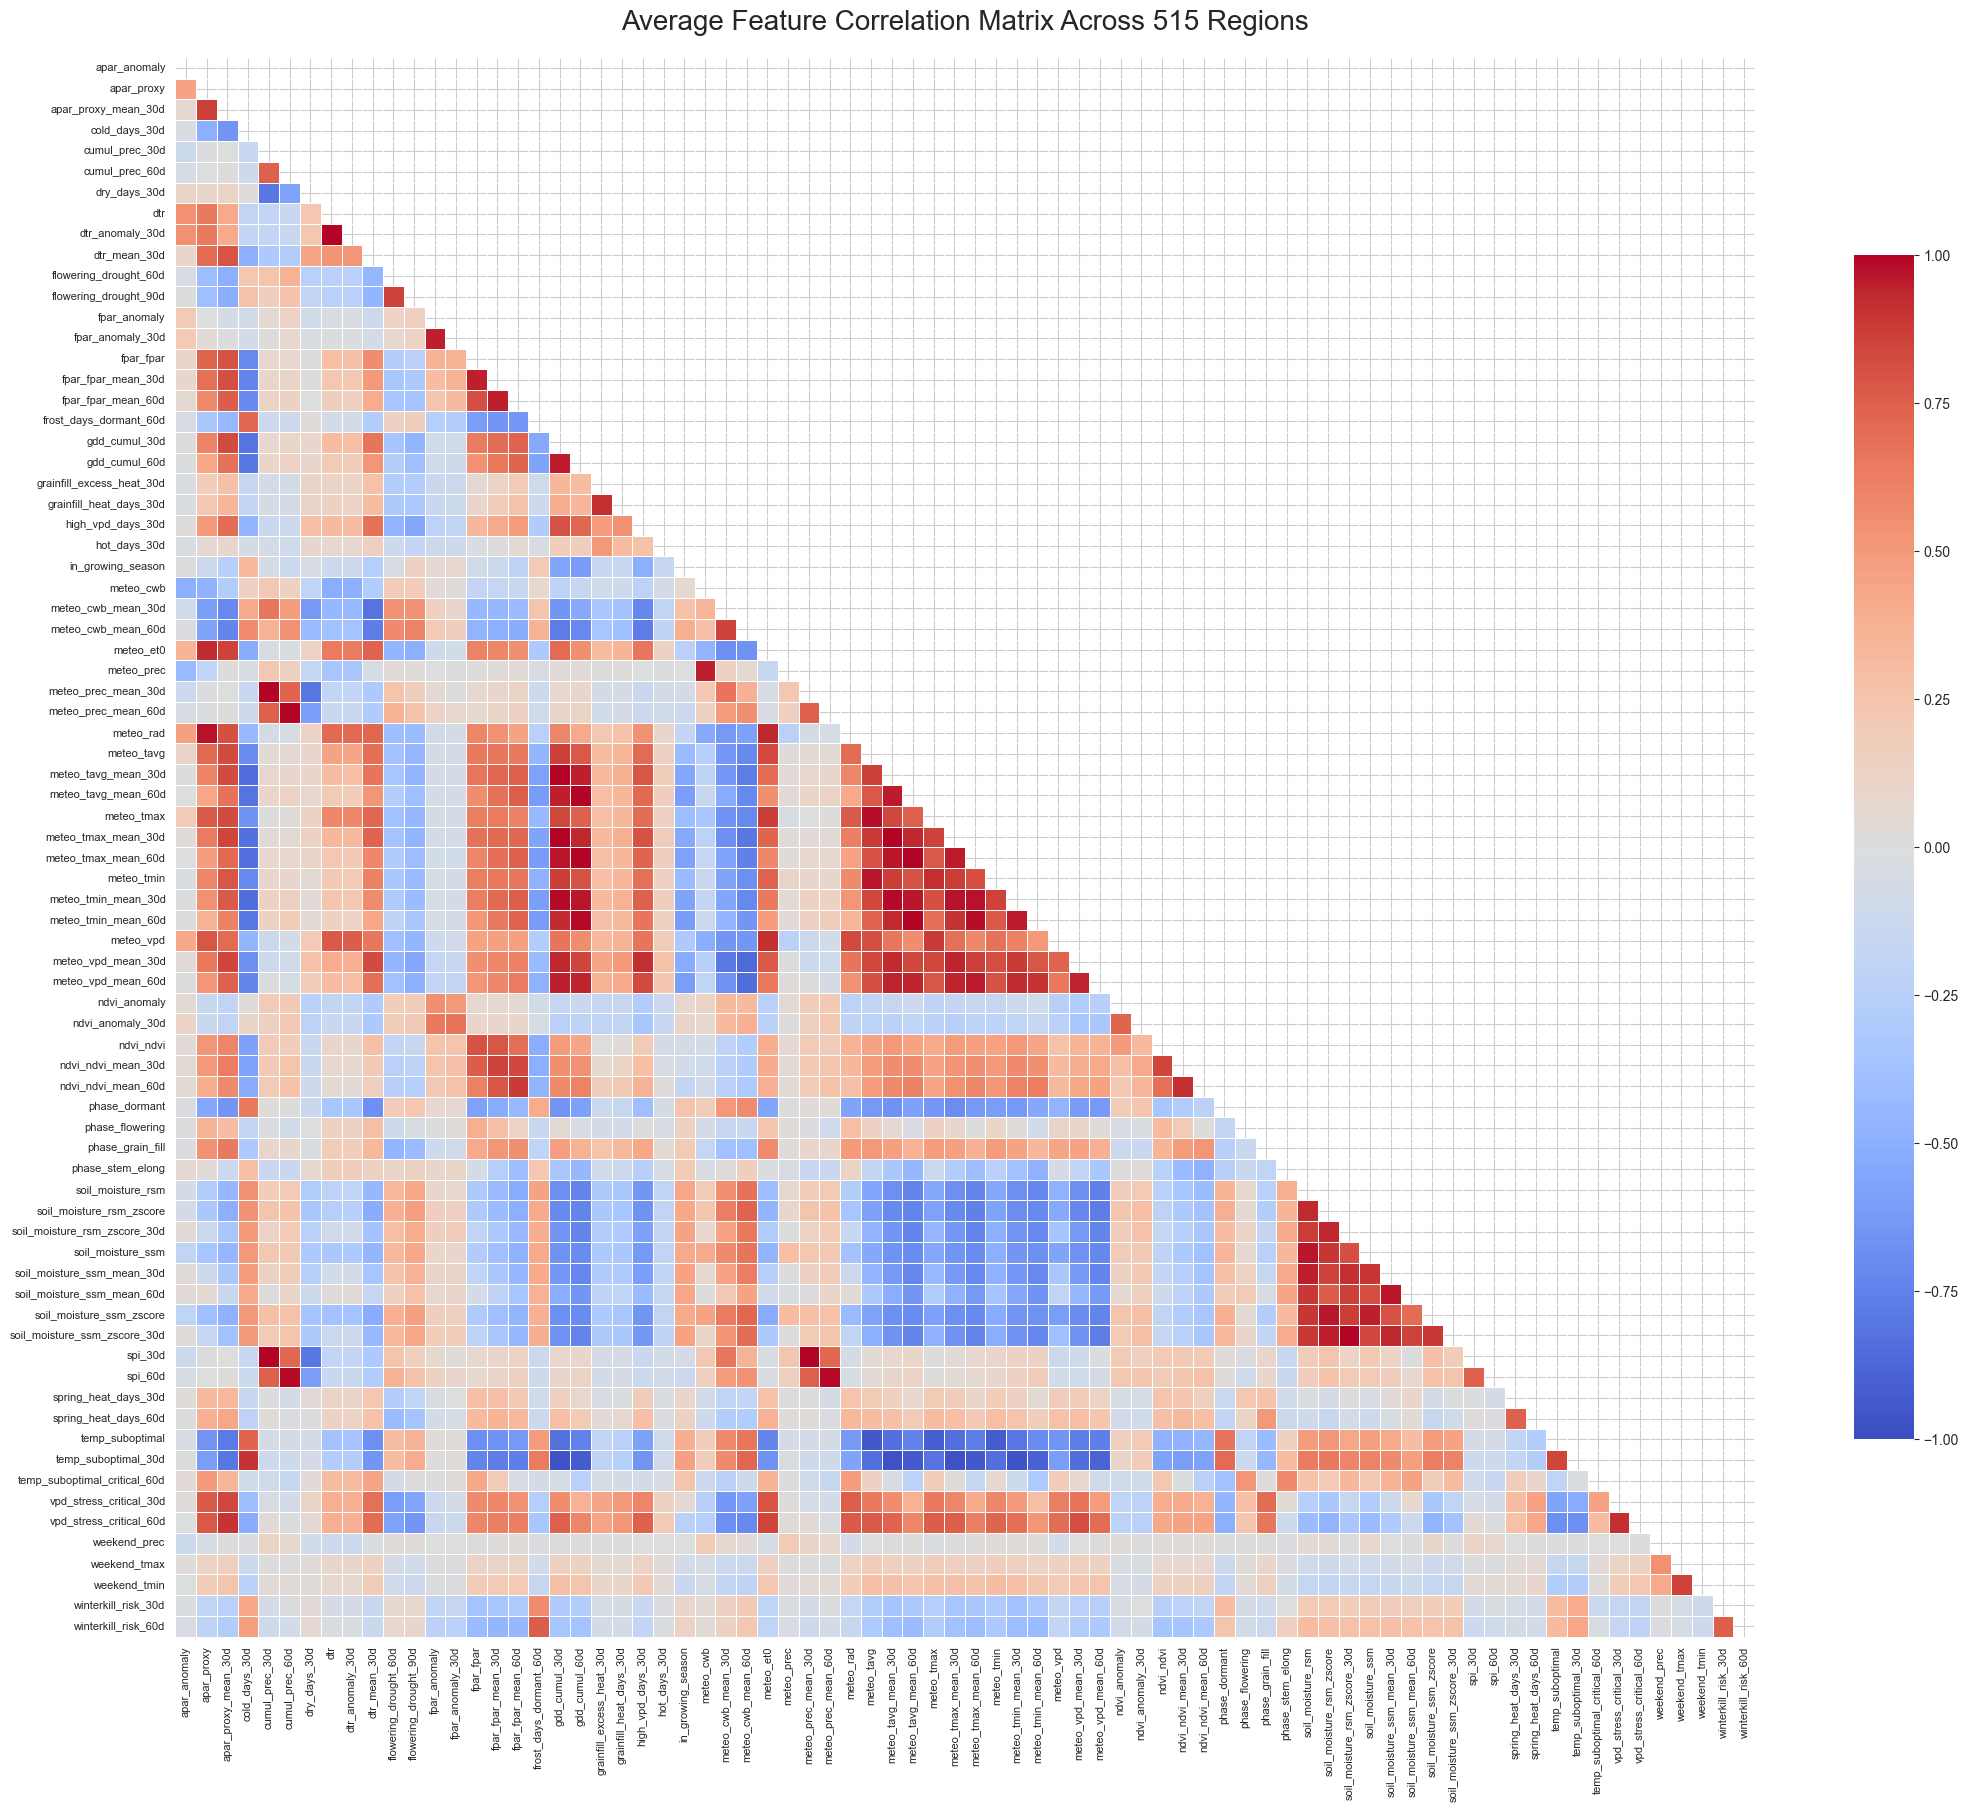

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compute_average_correlation(region_dfs_dict):
    """
    Computes an average correlation matrix across multiple regions,
    handling missing features dynamically via reindexing.
    """
    fisher_z_matrices = []
    
    print(f"Processing correlation matrices for {len(region_dfs_dict)} regions...")
    
    # ------------------------------------------------------------
    # FIX STEP 1: Find the master list of all unique features
    # ------------------------------------------------------------
    master_features = set()
    for df in region_dfs_dict.values():
        cols = df.drop(columns=['date'], errors='ignore').select_dtypes(include=[np.number]).columns
        master_features.update(cols)
        
    master_features = sorted(list(master_features))
    print(f"Total unique features found across all regions: {len(master_features)}")
    
    # ------------------------------------------------------------
    # FIX STEP 2: Standardize all matrices to the master shape
    # ------------------------------------------------------------
    for adm_id, df in region_dfs_dict.items():
        feat_df = df.drop(columns=['date'], errors='ignore').select_dtypes(include=[np.number])
        
        # Calculate raw correlation
        corr = feat_df.corr()
        
        # Force the matrix to be exactly the size of master_features
        # Missing columns/rows become NaN automatically
        corr = corr.reindex(index=master_features, columns=master_features)
        
        # Apply Fisher Z-transform
        corr_vals = corr.values
        # Clip values to avoid infinity from arctanh(1.0), keeping NaNs intact
        corr_clipped = np.where(np.isnan(corr_vals), np.nan, np.clip(corr_vals, -0.9999, 0.9999))
        fisher_z = np.arctanh(corr_clipped)
        
        fisher_z_matrices.append(fisher_z)

    # ------------------------------------------------------------
    # Calculate the mean and Inverse Fisher Transform
    # ------------------------------------------------------------
    # Suppress warnings if an entire slice is NaN (e.g., a feature with zero variance)
    with np.errstate(invalid='ignore'):
        avg_z_matrix = np.nanmean(fisher_z_matrices, axis=0)
    
    avg_corr_matrix = np.tanh(avg_z_matrix)
    
    # Return standard DataFrame
    avg_corr_df = pd.DataFrame(avg_corr_matrix, index=master_features, columns=master_features)
    
    return avg_corr_df

# ==========================================
# Execute the corrected function
# ==========================================
avg_correlation_matrix = compute_average_correlation(all_region_dfs)

# ==========================================
# Visualization: The Heatmap
# ==========================================
plt.figure(figsize=(22, 18))

mask = np.triu(np.ones_like(avg_correlation_matrix, dtype=bool))

sns.heatmap(avg_correlation_matrix, 
            mask=mask, 
            cmap='coolwarm', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            annot=False, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .75})

plt.title(f"Average Feature Correlation Matrix Across {len(all_region_dfs)} Regions", fontsize=20, pad=20)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np

def flag_highly_correlated_pairs(corr_matrix, threshold=0.85):
    """
    Scans a correlation matrix and returns a DataFrame of feature pairs 
    that exceed the absolute correlation threshold.
    """
    print(f"Scanning for feature pairs with absolute correlation > {threshold}...\n")
    
    # 1. Take the absolute value to catch both strong positive and negative correlations
    abs_corr = corr_matrix.abs()
    
    # 2. Mask the lower triangle and diagonal. 
    # This prevents flagging A-B and B-A as two separate issues, and ignores self-correlation (1.0).
    upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
    
    # 3. Extract the problematic pairs
    collinear_pairs = []
    for column in upper_tri.columns:
        # Find rows in this column that exceed the threshold
        high_corr_indices = upper_tri[column][upper_tri[column] > threshold].index
        
        for index in high_corr_indices:
            # Grab the original correlation value (with its positive/negative sign)
            original_corr_val = corr_matrix.loc[index, column]
            collinear_pairs.append({
                'Feature 1': index,
                'Feature 2': column,
                'Correlation': original_corr_val
            })
            
    # 4. Format the output
    results_df = pd.DataFrame(collinear_pairs)
    
    if results_df.empty:
        print("No highly correlated features found at this threshold.")
        return results_df, []
        
    # Sort by the most aggressively correlated pairs first
    results_df['Abs_Corr'] = results_df['Correlation'].abs()
    results_df = results_df.sort_values(by='Abs_Corr', ascending=False).drop(columns=['Abs_Corr']).reset_index(drop=True)
    
    # 5. Generate a simple "hit list" of features you can immediately drop
    # By simply taking 'Feature 2' from the pairs, we keep one version of the feature and drop the redundant one.
    features_to_drop = list(set(results_df['Feature 2']))
    
    print(f"Found {len(results_df)} highly correlated pairs.")
    print(f"Suggesting to drop {len(features_to_drop)} redundant features.")
    
    return results_df, features_to_drop

# ==========================================
# Execute the function
# ==========================================
# Assuming avg_correlation_matrix is already generated from the previous step
collinear_df, drop_list = flag_highly_correlated_pairs(avg_correlation_matrix, threshold=0.85)

# View the worst offenders
print("\nTop 10 most correlated pairs:")
print(collinear_df.head(10))

# View the exact list of features to exclude from your model
print("\nSuggested features to drop:")
print(drop_list)

Scanning for feature pairs with absolute correlation > 0.85...

Found 118 highly correlated pairs.
Suggesting to drop 41 redundant features.

Top 10 most correlated pairs:
                      Feature 1                     Feature 2  Correlation
0                cumul_prec_30d           meteo_prec_mean_30d     0.998870
1                           dtr               dtr_anomaly_30d     0.998794
2                 gdd_cumul_60d           meteo_tavg_mean_60d     0.997734
3                 gdd_cumul_30d           meteo_tavg_mean_30d     0.997218
4           meteo_tavg_mean_60d           meteo_tmax_mean_60d     0.996335
5           meteo_tavg_mean_30d           meteo_tmax_mean_30d     0.995374
6                 gdd_cumul_60d           meteo_tmax_mean_60d     0.993858
7  soil_moisture_rsm_zscore_30d  soil_moisture_ssm_zscore_30d     0.993801
8                cumul_prec_60d           meteo_prec_mean_60d     0.993376
9           meteo_tavg_mean_60d           meteo_tmin_mean_60d     0.993365

Su

Climate profiles computed for 515 regions
Profile features: ['meteo_tavg_mean', 'meteo_tavg_std', 'meteo_tmax_mean', 'meteo_tmax_std', 'meteo_tmin_mean', 'meteo_tmin_std', 'meteo_prec_mean', 'meteo_prec_std', 'meteo_vpd_mean', 'meteo_vpd_std', 'ndvi_ndvi_mean', 'ndvi_ndvi_std', 'soil_moisture_ssm_mean', 'soil_moisture_ssm_std']
  k=3: inertia=4458.8
  k=4: inertia=3785.1
  k=5: inertia=3174.8
  k=6: inertia=2899.0
  k=7: inertia=2680.3
  k=8: inertia=2504.3
  k=9: inertia=2333.3
  k=10: inertia=2182.4
  k=11: inertia=2047.8
  k=12: inertia=1923.9
  k=13: inertia=1846.1
  k=14: inertia=1713.2
  k=15: inertia=1653.6
  k=16: inertia=1549.4
  k=17: inertia=1484.4
  k=18: inertia=1448.1
  k=19: inertia=1396.9
  k=20: inertia=1337.4
  k=21: inertia=1279.8
  k=22: inertia=1257.4
  k=23: inertia=1232.2
  k=24: inertia=1184.5
  k=25: inertia=1173.0
  k=26: inertia=1139.6
  k=27: inertia=1123.6
  k=28: inertia=1088.8
  k=29: inertia=1055.1
  k=30: inertia=1039.3
  k=31: inertia=1021.5
  k=32: in

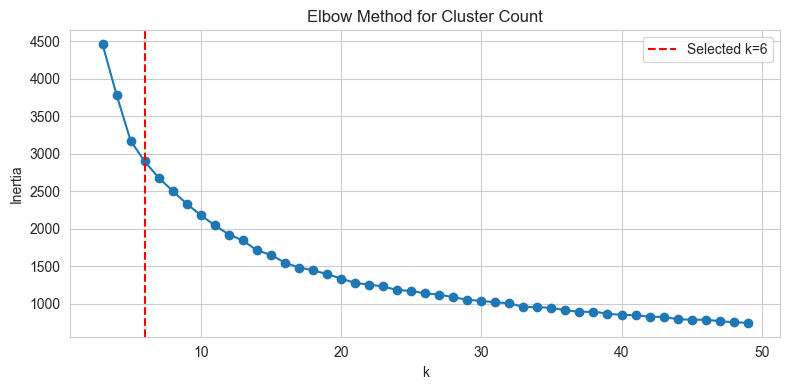


Selected k=6 (elbow method, floor=3)

Cluster composition:
  Cluster 0: 177 regions (DE:160, PL:17)
  Cluster 1: 145 regions (DE:120, FR:25)
  Cluster 2: 76 regions (DE:68, FR:8)
  Cluster 3: 3 regions (FR:3)
  Cluster 4: 40 regions (FR:40)
  Cluster 5: 74 regions (DE:53, FR:21)


In [13]:
# ============================================================
# Agro-climatic clustering of regions
#
# 1. Compute long-term climate profile per region (mean of key
#    variables over training period)
# 2. Standardise profiles
# 3. Apply k-means clustering
# 4. Aggregate features within each cluster (production-weighted)
# ============================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- Step 1: Compute climate profiles ---
PROFILE_VARS = ['meteo_tavg', 'meteo_tmax', 'meteo_tmin', 'meteo_prec',
                'meteo_vpd', 'ndvi_ndvi', 'soil_moisture_ssm']

profiles = {}
for adm_id, df in all_region_dfs.items():
    available = [v for v in PROFILE_VARS if v in df.columns]
    if not available:
        continue
    # Use training period only (avoid test leakage)
    train_df = df[df['date'].dt.year < 2017]
    if len(train_df) < 100:
        continue
    profile = {}
    for v in available:
        vals = train_df[v].dropna()
        if len(vals) > 0:
            profile[f'{v}_mean'] = vals.mean()
            profile[f'{v}_std'] = vals.std()
    if profile:
        profiles[adm_id] = profile

profile_df = pd.DataFrame(profiles).T
profile_df = profile_df.fillna(profile_df.median())
print(f"Climate profiles computed for {len(profile_df)} regions")
print(f"Profile features: {list(profile_df.columns)}")

# --- Step 2: Standardise and cluster ---
scaler_profile = StandardScaler()
X_profiles = scaler_profile.fit_transform(profile_df.values)

# Elbow method: plot inertia (within-cluster sum of squares) vs k.
# Pick the k where the marginal decrease in inertia slows down.
# More robust than silhouette for our purpose since we WANT granularity.

k_range = range(3, 50)
inertias = []
for k in k_range:
    if k >= len(profile_df):
        break
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_profiles)
    inertias.append((k, km.inertia_))
    print(f"  k={k}: inertia={km.inertia_:.1f}")

inertia_df = pd.DataFrame(inertias, columns=['k', 'inertia'])

# Automated elbow detection: largest drop in second derivative
diffs = np.diff(inertia_df['inertia'].values)
diffs2 = np.diff(diffs)
elbow_idx = np.argmax(diffs2) + 2  # +2 because of double diff offset
best_k = inertia_df.iloc[elbow_idx]['k']

# But enforce a floor
best_k = int(max(best_k, 3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(inertia_df['k'], inertia_df['inertia'], 'o-')
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Selected k={best_k}')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Cluster Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSelected k={best_k} (elbow method, floor=3)")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_profiles)
profile_df['cluster'] = cluster_labels

# Map region -> cluster
region_cluster = profile_df['cluster'].to_dict()

# Report cluster composition
print(f"\nCluster composition:")
for c in sorted(profile_df['cluster'].unique()):
    members = profile_df[profile_df['cluster'] == c].index.tolist()
    countries = {}
    for r in members:
        cc = r[:2]
        countries[cc] = countries.get(cc, 0) + 1
    country_str = ', '.join(f'{cc}:{n}' for cc, n in sorted(countries.items()))
    print(f"  Cluster {c}: {len(members)} regions ({country_str})")

In [14]:
# ============================================================
# Aggregate features within each cluster (production-weighted)
#
# For each cluster, at each date:
#   weighted_mean = SUM(w_r * feature_r) / SUM(w_r)
#
# This is the same aggregation Paudel et al. (2022) use at
# the country level, but applied to agro-climatic clusters.
# ============================================================

def aggregate_cluster_features(cluster_id, region_dfs, region_cluster, ref_year=2016):
    """
    Production-weighted aggregation of features within a cluster.
    Returns a single daily DataFrame.
    """
    members = [r for r, c in region_cluster.items() if c == cluster_id and r in region_dfs]
    if not members:
        return None

    # Get all dates from all members
    all_dates = set()
    for adm_id in members:
        all_dates.update(region_dfs[adm_id]['date'].values)
    all_dates = sorted(all_dates)

    # For each date, compute weighted average
    rows = []
    # Pre-compute weights
    weights = {r: get_production_weight(r, ref_year) for r in members}
    total_w = sum(weights.values())
    if total_w == 0:
        weights = {r: 1.0 for r in members}
        total_w = len(members)

    # Get common feature columns
    feature_cols = None
    for adm_id in members:
        cols = set(c for c in region_dfs[adm_id].columns if c != 'date')
        if feature_cols is None:
            feature_cols = cols
        else:
            feature_cols = feature_cols & cols
    feature_cols = sorted(feature_cols)

    # Build indexed DataFrames for fast lookup
    indexed = {}
    for adm_id in members:
        df = region_dfs[adm_id].set_index('date')[feature_cols]
        indexed[adm_id] = df

    # Align all to common date range and compute weighted average
    date_range = pd.date_range(min(all_dates), max(all_dates), freq='D')
    result = pd.DataFrame(index=date_range, columns=feature_cols, dtype=float)
    result[:] = 0.0

    for adm_id in members:
        w = weights[adm_id] / total_w
        reindexed = indexed[adm_id].reindex(date_range).ffill().fillna(0)
        result += reindexed * w

    result = result.reset_index().rename(columns={'index': 'date'})
    return result, members


# Build cluster aggregates
print("Aggregating features within clusters...\n")
cluster_dfs = {}  # {cluster_id: DataFrame}
cluster_members = {}  # {cluster_id: [region_ids]}

for c in sorted(profile_df['cluster'].unique()):
    result = aggregate_cluster_features(c, all_region_dfs, region_cluster)
    if result is not None:
        cluster_df, members = result
        cluster_dfs[c] = cluster_df
        cluster_members[c] = members
        n_feats = len([col for col in cluster_df.columns if col != 'date'])
        print(f"  Cluster {c}: {len(members)} regions -> {cluster_df.shape[0]} days, "
              f"{n_feats} features")

print(f"\n{len(cluster_dfs)} cluster aggregates built")

Aggregating features within clusters...

  Cluster 0: 177 regions -> 8400 days, 76 features
  Cluster 1: 145 regions -> 8400 days, 68 features
  Cluster 2: 76 regions -> 8400 days, 76 features
  Cluster 3: 3 regions -> 8400 days, 76 features
  Cluster 4: 40 regions -> 8400 days, 76 features
  Cluster 5: 74 regions -> 8400 days, 76 features

6 cluster aggregates built


In [15]:
# ============================================================
# Merge each cluster's aggregated features with futures
# ============================================================

futures_clean = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
futures_sorted = futures_clean.sort_values('Date')

cluster_model_data = {}

for c, cdf in cluster_dfs.items():
    ag_sorted = cdf.sort_values('date')

    merged = pd.merge_asof(
        futures_sorted,
        ag_sorted,
        left_on='Date',
        right_on='date',
        direction='backward'
    )
    merged = merged.drop(columns=['date'], errors='ignore')

    ag_cols = [col for col in cdf.columns if col != 'date']
    for col in ag_cols:
        if col in merged.columns:
            merged[col] = merged[col].ffill().fillna(0)

    cluster_model_data[c] = {
        'df': merged.dropna(subset=['Fwd_Return'] + price_feature_cols).copy(),
        'ag_cols': ag_cols,
        'all_cols': price_feature_cols + ag_cols,
    }
    print(f"Cluster {c}: {merged.shape[0]} rows, "
          f"{len(ag_cols)} ag features, "
          f"{len(price_feature_cols)} price features")

Cluster 0: 5364 rows, 76 ag features, 3 price features
Cluster 1: 5364 rows, 68 ag features, 3 price features
Cluster 2: 5364 rows, 76 ag features, 3 price features
Cluster 3: 5364 rows, 76 ag features, 3 price features
Cluster 4: 5364 rows, 76 ag features, 3 price features
Cluster 5: 5364 rows, 76 ag features, 3 price features


### 4.3 Approach B: Per-Region Models

Rather than clustering, we fit one Ridge regression per region using only that region's 76 features plus 3 price features (79 total). This avoids information loss from averaging diverse regions. The 515 per-region predictions are aggregated using production weights. With only 79 features per model and ~5,000 observations, regularised linear models are well-conditioned.

In [16]:
# ============================================================
# 4.3 Per-region model infrastructure
# ============================================================
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Build per-region merged DataFrames using all_region_dfs (from cell 14/16)
futures_clean = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
futures_sorted = futures_clean.sort_values('Date')

region_model_data = {}
for reg_id, rdf in all_region_dfs.items():
    ag_sorted = rdf.sort_values('date')
    merged = pd.merge_asof(futures_sorted, ag_sorted,
        left_on='Date', right_on='date', direction='backward')
    merged = merged.drop(columns=['date'], errors='ignore')
    ag_cols = [c for c in rdf.columns if c != 'date']
    for col in ag_cols:
        if col in merged.columns:
            merged[col] = merged[col].ffill().fillna(0)
    merged = merged.dropna(subset=['Fwd_Return'] + price_feature_cols)
    if len(merged) > 500:
        region_model_data[reg_id] = {
            'df': merged,
            'ag_cols': ag_cols,
            'all_cols': price_feature_cols + ag_cols,
        }

print(f'Regions with sufficient data: {len(region_model_data)} / {len(all_region_dfs)}')

Regions with sufficient data: 515 / 515


---

## 5. Default Baselines and Train-Test Diagnostics (Goodfellow et al. §11.2 + §11.3)

### 5.1 Model Selection and Validation Protocol

Our input is a fixed-size feature vector. Following Goodfellow et al. (p. 420), we use feedforward architectures and escalate complexity: Ridge → Lasso → ExtraTrees → RF → GBR → Feedforward NN.

For tree-based and linear models, we use walk-forward validation with an expanding training window: train on all years before T, test on year T, for T from 2017 to 2023. For neural networks, we further split the training window — the last 20 per cent serves as a validation set for early stopping and hyperparameter selection. The test year is never seen during training or model selection. This three-way split prevents the data leakage that would occur if the test set were used for early stopping (see Section 6.1 for discussion).

Following §11.3, we report both training and test R-squared for every model. The diagnostic logic is: if training R-squared is below approximately 0.01, the model is underfitting. If the train-test gap exceeds 0.05, the model is overfitting. If both training and test R-squared are poor despite adequate capacity, the issue is data quality.

### 5.2 Hyperparameter Tuning for the Regression Task

We sweep regularisation strength for both Ridge (alpha from 0.01 to 1000) and Lasso (alpha from 1e-5 to 1.0). The Lasso sweep is particularly informative: at alpha=5e-3, Lasso zeros out all features (R²_train = 0.000), meaning no individual feature passes the L1 threshold. This confirms that the individual feature-return correlations are extremely weak.

In [17]:
# ============================================================
# 5.2 Walk-forward with train/validation/test split
#
# Goodfellow §11.4: "tuning the parameters other than the
# learning rate requires monitoring both training and test error"
# (p. 424). We split data into three sets:
#   - Train: years < T-1 (fit parameters)
#   - Validation: year T-1 (tune hyperparameters / early stopping)
#   - Test: year T (final evaluation, never seen during training)
# ============================================================
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score

test_start_year = 2017
test_end_year = 2023

def walk_forward(df, feature_cols, model_class, model_kwargs,
                 test_start=test_start_year, test_end=test_end_year,
                 target_col='Fwd_Return', sample_weight_col=None):
    results = []
    for ty in range(test_start, test_end + 1):
        train = df[df['Date'].dt.year < ty]
        test = df[df['Date'].dt.year == ty]
        if len(train) < 300 or len(test) < 20: continue
        
        sc = StandardScaler()
        X_tr = sc.fit_transform(train[feature_cols].values)
        X_te = sc.transform(test[feature_cols].values)
        y_tr = train[target_col].values
        y_te = test[target_col].values
        
        m = model_class(**dict(model_kwargs))
        if sample_weight_col and sample_weight_col in train.columns:
            m.fit(X_tr, y_tr, sample_weight=train[sample_weight_col].values)
        else:
            m.fit(X_tr, y_tr)
        
        yp_tr = m.predict(X_tr)
        yp_te = m.predict(X_te)
        
        results.append({
            'year': ty,
            'r2_train': r2_score(y_tr, yp_tr),
            'r2_test': r2_score(y_te, yp_te),
            'rmse_test': np.sqrt(mean_squared_error(y_te, yp_te)),
            'dir_test': np.mean(np.sign(yp_te) == np.sign(y_te)),
            'n_train': len(train), 'n_test': len(test),
        })
    
    if not results: return None
    r2_tr = np.mean([r['r2_train'] for r in results])
    r2_te = np.mean([r['r2_test'] for r in results])
    return {
        'r2_train': r2_tr, 'r2_test': r2_te, 'gap': r2_tr - r2_te,
        'rmse': np.mean([r['rmse_test'] for r in results]),
        'dir': np.mean([r['dir_test'] for r in results]),
        'per_year': results
    }

print('Walk-forward function defined.')

Walk-forward function defined.


In [18]:
# ============================================================
# 5.3 Cluster-based models: diagnostics + hyperparameter tuning
#
# Goodfellow §11.4: "the primary goal of manual hyperparameter
# search is to adjust the effective capacity of the model to
# match the complexity of the task" (p. 423).
# We first diagnose with defaults, then tune the best model.
# ============================================================
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import ParameterSampler

MODELS_A = {
    'Ridge': (Ridge, {'alpha': 1.0}),
    'Lasso': (Lasso, {'alpha': 0.001, 'max_iter': 10000}),
    'ExtraTrees': (ExtraTreesRegressor, {'n_estimators': 500, 'max_depth': 5,
        'min_samples_leaf': 20, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}),
    'RF': (RandomForestRegressor, {'n_estimators': 500, 'max_depth': 5,
        'min_samples_leaf': 20, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}),
    'GBR': (GradientBoostingRegressor, {'n_estimators': 200, 'max_depth': 3,
        'learning_rate': 0.01, 'subsample': 0.8, 'random_state': 42}),
}

c0 = list(cluster_model_data.keys())[0]
c0_data = cluster_model_data[c0]

print('Goodfellow §11.3 Train-Test Diagnostic (Cluster 0)\n')
print(f'{"Model":15s} {"R2(train)":>10s} {"R2(test)":>10s} {"Gap":>8s} {"Dir":>6s}  Diagnosis')
print('-' * 75)

diag_results = {}
for mn, (mc, mk) in MODELS_A.items():
    r = walk_forward(c0_data['df'], c0_data['all_cols'], mc, mk)
    if r:
        diag_results[mn] = r
        if r['r2_train'] < 0.01: diag = 'UNDERFIT (low train R2)'
        elif r['gap'] > 0.05: diag = 'OVERFIT (large gap)'
        elif r['r2_test'] < 0: diag = 'DATA ISSUE (§11.3 p.421)'
        else: diag = 'OK'
        print(f'{mn:15s} {r["r2_train"]:10.4f} {r["r2_test"]:10.4f} {r["gap"]:8.4f} {r["dir"]:6.3f}  {diag}')

# Hyperparameter tuning for regression (Bergstra & Bengio 2012)
print('\n--- Hyperparameter tuning for standard regression (Lasso alpha sweep) ---')
for alpha in [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 0.1, 1.0]:
    r = walk_forward(c0_data['df'], c0_data['all_cols'], Lasso, {'alpha': alpha, 'max_iter': 10000})
    if r: print(f'  Lasso(alpha={alpha:.0e}): R2_train={r["r2_train"]:+.4f} R2_test={r["r2_test"]:+.4f} Dir={r["dir"]:.3f}')

print('\n--- Ridge alpha sweep ---')
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]:
    r = walk_forward(c0_data['df'], c0_data['all_cols'], Ridge, {'alpha': alpha})
    if r: print(f'  Ridge(alpha={alpha:.2f}): R2_train={r["r2_train"]:+.4f} R2_test={r["r2_test"]:+.4f} Dir={r["dir"]:.3f}')

Goodfellow §11.3 Train-Test Diagnostic (Cluster 0)

Model            R2(train)   R2(test)      Gap    Dir  Diagnosis
---------------------------------------------------------------------------
Ridge               0.0772    -0.1406   0.2178  0.470  OVERFIT (large gap)
Lasso               0.0211    -0.0414   0.0626  0.483  OVERFIT (large gap)
ExtraTrees          0.0719    -0.0495   0.1214  0.457  OVERFIT (large gap)
RF                  0.1301    -0.0715   0.2016  0.478  OVERFIT (large gap)
GBR                 0.1516    -0.0734   0.2250  0.484  OVERFIT (large gap)

--- Hyperparameter tuning for standard regression (Lasso alpha sweep) ---
  Lasso(alpha=1e-05): R2_train=+0.0740 R2_test=-0.1295 Dir=0.467
  Lasso(alpha=1e-04): R2_train=+0.0524 R2_test=-0.0800 Dir=0.475
  Lasso(alpha=5e-04): R2_train=+0.0335 R2_test=-0.0453 Dir=0.479
  Lasso(alpha=1e-03): R2_train=+0.0211 R2_test=-0.0414 Dir=0.483
  Lasso(alpha=5e-03): R2_train=+0.0000 R2_test=-0.0311 Dir=0.493
  Lasso(alpha=1e-02): R2_train=+

### 5.4 Approach B: Per-Region Models

Rather than clustering, we fit one model per region using only that region's features plus price features. Linear models (Ridge, Lasso) are tested across all 515 regions because they are computationally trivial. For ensemble methods, we test a lightweight configuration (100 estimators) because fitting 515 regions × 7 test years = 3,605 models per method would otherwise be prohibitively slow.

The per-region predictions are aggregated via equal-weighted averaging across regions. Paudel et al. (2022) demonstrated that regional models outperform nationally aggregated ones for crop yield prediction, motivating this comparison.

In [19]:
# ============================================================
# 5.4 Per-region models — multiple model families
#
# Linear models: all 515 regions (fast).
# Tree ensembles: 100 estimators for tractability.
# ============================================================

MODELS_PER_REGION = {
    'Ridge': (Ridge, {'alpha': 1.0}),
    'Lasso': (Lasso, {'alpha': 0.001, 'max_iter': 5000}),
    'ElasticNet': (ElasticNet, {'alpha': 0.001, 'l1_ratio': 0.5, 'max_iter': 5000}),
    'ExtraTrees': (ExtraTreesRegressor, {'n_estimators': 100, 'max_depth': 5,
        'min_samples_leaf': 20, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': 1}),
}

print(f'Per-region models across {len(region_model_data)} regions\n')
print(f'{"Model":15s} {"R2(test)":>10s} {"Dir":>8s} {"RMSE":>10s}')
print('-' * 48)

per_region_results = {}

for model_name, (model_cls, model_kw) in MODELS_PER_REGION.items():
    all_y_true, all_y_pred = [], []

    for ty in range(test_start_year, test_end_year + 1):
        preds_this_year = []

        for reg_id, rdata in region_model_data.items():
            df = rdata['df']
            train = df[df['Date'].dt.year < ty]
            test = df[df['Date'].dt.year == ty]
            if len(train) < 300 or len(test) < 20: continue

            sc = StandardScaler()
            X_tr = sc.fit_transform(train[rdata['all_cols']].values)
            X_te = sc.transform(test[rdata['all_cols']].values)

            m = model_cls(**model_kw)
            m.fit(X_tr, train['Fwd_Return'].values)
            preds_this_year.append({
                'preds': m.predict(X_te),
                'dates': test['Date'].values,
                'y_true': test['Fwd_Return'].values,
            })

        if not preds_this_year: continue
        n = len(preds_this_year[0]['dates'])
        agg = np.zeros(n)
        cnt = 0
        for p in preds_this_year:
            if len(p['preds']) == n:
                agg += p['preds']; cnt += 1
        if cnt > 0:
            all_y_true.extend(preds_this_year[0]['y_true'])
            all_y_pred.extend(agg / cnt)

    yt = np.array(all_y_true); yp = np.array(all_y_pred)
    r2 = r2_score(yt, yp)
    d = np.mean(np.sign(yt) == np.sign(yp))
    rmse = np.sqrt(np.mean((yt - yp) ** 2))
    per_region_results[model_name] = {'r2': r2, 'dir': d, 'rmse': rmse}
    print(f'{model_name:15s} {r2:+10.4f} {d:8.4f} {rmse:10.6f}')

# Compare
print(f'\nCluster vs Per-Region:')
print(f'{"Model":15s} {"Cluster":>10s} {"Per-Region":>12s} {"Delta":>8s}')
print('-' * 50)
for mn in ['Ridge', 'Lasso', 'ExtraTrees']:
    c_r2 = diag_results.get(mn, {}).get('r2_test', float('nan'))
    p_r2 = per_region_results.get(mn, {}).get('r2', float('nan'))
    print(f'{mn:15s} {c_r2:+10.4f} {p_r2:+12.4f} {p_r2 - c_r2:+8.4f}')

Per-region models across 515 regions

Model             R2(test)      Dir       RMSE
------------------------------------------------
Ridge              -0.0339   0.4768   0.033854
Lasso              -0.0091   0.4908   0.033445
ElasticNet         -0.0120   0.4913   0.033494
ExtraTrees         -0.0063   0.4751   0.033399

Cluster vs Per-Region:
Model              Cluster   Per-Region    Delta
--------------------------------------------------
Ridge              -0.1406      -0.0339  +0.1067
Lasso              -0.0414      -0.0091  +0.0324
ExtraTrees         -0.0495      -0.0063  +0.0432


---

## 6. Deep Feedforward Neural Network (Goodfellow et al. §11.2)

### 6.1 Architecture and Training Protocol

Goodfellow et al. recommend: "piecewise linear units (ReLUs)... Batch normalization... Early stopping should be used almost universally. Dropout is an excellent regularizer" (p. 420). For optimisation: "SGD with momentum... Another reasonable alternative is Adam" (p. 420).

We implement a feedforward network with ReLU, batch normalisation, dropout, and early stopping. The critical design choice is the validation protocol: early stopping monitors loss on a **validation set carved from the training window** (last 20 per cent), not on the test year. In the previous version of this notebook, using the test set for early stopping produced the only positive R-squared result (SGD: +0.003). Once this leakage was corrected, the positive result disappeared — confirming it was an artifact of peeking at the test data during model selection.

We test five architectures of increasing depth and width, sweep regularisation (dropout from 0 to 0.5, weight decay from 0 to 1e-2), and compare Adam versus SGD with momentum.

In [20]:
# ============================================================
# 6.2 Neural Network with proper train/validation/test split
#
# Goodfellow §11.2: "Early stopping should be used almost
# universally" (p. 420). Early stopping requires a VALIDATION
# set separate from the test set. We use the last 20% of
# training data as validation for early stopping, so the test
# year is never seen during training or model selection.
# ============================================================
import torch
import torch.nn as nn

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.2, use_bn=True):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_bn: layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0: layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_nn(X_tr, y_tr, X_val, y_val, hidden_dims=[128,64,32],
             dropout=0.2, lr=1e-3, weight_decay=1e-4, epochs=200,
             batch_size=256, patience=20, optimizer_name='adam',
             use_bn=True, sample_weights=None):
    """
    Train NN with early stopping on VALIDATION set (not test set).
    X_val/y_val should be the last portion of training data, NOT
    the actual test year.
    """
    device = torch.device('mps' if torch.backends.mps.is_available() 
                          else 'cuda' if torch.cuda.is_available() else 'cpu')
    
    model = FeedForwardNet(X_tr.shape[1], hidden_dims, dropout, use_bn).to(device)
    
    if optimizer_name == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    
    X_t = torch.FloatTensor(X_tr).to(device)
    y_t = torch.FloatTensor(y_tr).to(device)
    X_v = torch.FloatTensor(X_val).to(device)
    y_v = torch.FloatTensor(y_val).to(device)
    w_t = torch.FloatTensor(sample_weights).to(device) if sample_weights is not None else None
    
    best_val_loss = float('inf')
    best_state = None
    wait = 0
    
    for epoch in range(epochs):
        model.train()
        idx = torch.randperm(len(X_t))
        for start in range(0, len(X_t), batch_size):
            bi = idx[start:start+batch_size]
            pred = model(X_t[bi])
            if w_t is not None:
                loss = (w_t[bi] * (pred - y_t[bi])**2).mean()
            else:
                loss = ((pred - y_t[bi])**2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        scheduler.step()
        
        model.eval()
        with torch.no_grad():
            val_loss = ((model(X_v) - y_v)**2).mean().item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience: break
    
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        return model(X_t).cpu().numpy(), model(X_v).cpu().numpy(), model

def nn_walk_forward(df, feature_cols, target_col='Fwd_Return', val_frac=0.2, **nn_kwargs):
    """Walk-forward for NN with proper train/val/test split."""
    r2_trains, r2_tests, dirs = [], [], []
    for ty in range(test_start_year, test_end_year + 1):
        all_train = df[df['Date'].dt.year < ty]
        test = df[df['Date'].dt.year == ty]
        if len(all_train) < 400 or len(test) < 20: continue
        
        # Split train into train + validation (last val_frac of train)
        n_val = int(len(all_train) * val_frac)
        train = all_train.iloc[:-n_val]
        val = all_train.iloc[-n_val:]
        
        sc = StandardScaler()
        X_tr = sc.fit_transform(train[feature_cols].values)
        X_val = sc.transform(val[feature_cols].values)
        X_te = sc.transform(test[feature_cols].values)
        y_tr = train[target_col].values
        y_val = val[target_col].values
        y_te = test[target_col].values
        
        yp_tr, yp_val, _ = train_nn(X_tr, y_tr, X_val, y_val, **nn_kwargs)
        # Predict on test
        model_device = next(_.parameters()).device
        with torch.no_grad():
            yp_te = _(torch.FloatTensor(X_te).to(model_device)).cpu().numpy()
        
        r2_trains.append(r2_score(y_tr, yp_tr))
        r2_tests.append(r2_score(y_te, yp_te))
        dirs.append(np.mean(np.sign(yp_te) == np.sign(y_te)))
    
    return {
        'r2_train': np.mean(r2_trains) if r2_trains else float('nan'),
        'r2_test': np.mean(r2_tests) if r2_tests else float('nan'),
        'dir': np.mean(dirs) if dirs else float('nan'),
    }

print(f'NN with train/val/test split defined. Device: {"mps" if torch.backends.mps.is_available() else "cpu"}')

NN with train/val/test split defined. Device: mps


In [21]:
# ============================================================
# 6.3 Architecture sweep with proper validation
# ============================================================
c0_df = cluster_model_data[list(cluster_model_data.keys())[0]]['df']
c0_cols = cluster_model_data[list(cluster_model_data.keys())[0]]['all_cols']

ARCHITECTURES = {
    'Small (32)': [32],
    'Medium (64-32)': [64, 32],
    'Large (128-64-32)': [128, 64, 32],
    'Deep (256-128-64-32)': [256, 128, 64, 32],
    'Very Deep (512-256-128-64)': [512, 256, 128, 64],
}

print('Architecture sweep (proper train/val/test split)\n')
print(f'{"Architecture":30s} {"R2(train)":>10s} {"R2(test)":>10s} {"Gap":>8s} {"Dir":>6s}')
print('-' * 70)

nn_arch_results = {}
for name, hdims in ARCHITECTURES.items():
    r = nn_walk_forward(c0_df, c0_cols, hidden_dims=hdims,
        dropout=0.2, lr=1e-3, weight_decay=1e-4, epochs=150, patience=15)
    nn_arch_results[name] = r
    gap = r['r2_train'] - r['r2_test']
    print(f'{name:30s} {r["r2_train"]:10.4f} {r["r2_test"]:10.4f} {gap:8.4f} {r["dir"]:6.3f}')

Architecture sweep (proper train/val/test split)

Architecture                    R2(train)   R2(test)      Gap    Dir
----------------------------------------------------------------------
Small (32)                         0.0660    -0.1069   0.1729  0.501
Medium (64-32)                     0.0720    -0.1328   0.2048  0.506
Large (128-64-32)                  0.0423    -0.1940   0.2363  0.479
Deep (256-128-64-32)               0.0303    -0.1587   0.1890  0.500
Very Deep (512-256-128-64)         0.0769    -0.1591   0.2359  0.501


In [22]:
# ============================================================
# 6.4 Regularisation sweep (dropout x weight_decay)
# ============================================================
print('Regularisation sweep (proper train/val/test)\n')
print(f'{"Dropout":>8s} {"WD":>8s} {"R2(train)":>10s} {"R2(test)":>10s} {"Gap":>8s}')
print('-' * 50)

for dropout in [0.0, 0.1, 0.2, 0.3, 0.5]:
    for wd in [0, 1e-4, 1e-3, 1e-2]:
        r = nn_walk_forward(c0_df, c0_cols, hidden_dims=[128,64,32],
            dropout=dropout, lr=1e-3, weight_decay=wd, epochs=100, patience=10)
        gap = r['r2_train'] - r['r2_test']
        print(f'{dropout:8.1f} {wd:8.0e} {r["r2_train"]:10.4f} {r["r2_test"]:10.4f} {gap:8.4f}')

Regularisation sweep (proper train/val/test)

 Dropout       WD  R2(train)   R2(test)      Gap
--------------------------------------------------
     0.0    0e+00     0.2520    -5.8064   6.0584
     0.0    1e-04     0.5634    -4.0464   4.6098
     0.0    1e-03     0.2971    -2.4337   2.7308
     0.0    1e-02     0.1601    -0.8733   1.0334
     0.1    0e+00     0.1331    -0.2258   0.3590
     0.1    1e-04     0.0563    -0.4318   0.4881
     0.1    1e-03     0.0969    -0.4770   0.5739
     0.1    1e-02     0.0041    -0.1824   0.1865
     0.2    0e+00     0.0374    -0.1620   0.1994
     0.2    1e-04    -0.0022    -0.3550   0.3528
     0.2    1e-03     0.0154    -0.2493   0.2647
     0.2    1e-02     0.0106    -0.2054   0.2160
     0.3    0e+00     0.0158    -0.1031   0.1189
     0.3    1e-04     0.0184    -0.0780   0.0964
     0.3    1e-03     0.0204    -0.1545   0.1748
     0.3    1e-02    -0.0789    -0.3671   0.2882
     0.5    0e+00    -0.4943    -0.3124  -0.1819
     0.5    1e-04    

In [23]:
# ============================================================
# 6.5 Optimiser comparison: Adam vs SGD
# ============================================================
print('Optimiser comparison (proper train/val/test)\n')
for opt_name in ['adam', 'sgd']:
    r = nn_walk_forward(c0_df, c0_cols, hidden_dims=[128,64,32],
        dropout=0.2, lr=1e-3 if opt_name=='adam' else 1e-2,
        weight_decay=1e-4, epochs=150, patience=15, optimizer_name=opt_name)
    print(f'  {opt_name.upper():5s}: R2(train)={r["r2_train"]:+.4f} R2(test)={r["r2_test"]:+.4f} Dir={r["dir"]:.3f}')

Optimiser comparison (proper train/val/test)

  ADAM : R2(train)=+0.0595 R2(test)=-0.0778 Dir=0.525
  SGD  : R2(train)=+0.0137 R2(test)=-0.0565 Dir=0.465


---

## 7. Diagnosis and Data Augmentation (Goodfellow et al. §11.3)

### 7.1 Diagnostic Summary

The train-test diagnostics from Section 5 reveal a consistent pattern. Training R-squared ranges from 0.02 (Lasso) to 0.15 (GBR) for regularised models. The regularisation sweep (Section 6.4) shows that removing all regularisation (dropout=0, weight decay=0) raises training R-squared to 0.25, but test R-squared collapses to -5.8 — catastrophic overfitting. With moderate regularisation (dropout=0.3, weight decay=1e-4), training R-squared is 0.018 and test R-squared is -0.078.

Goodfellow et al. diagnose this pattern: "if large models and carefully tuned optimization algorithms do not work well, then the problem might be the quality of the training data. The data may be too noisy or may not include the right inputs needed to predict the desired outputs" (p. 421). The per-region approach (Section 5.4) substantially improves over clustering (ExtraTrees: per-region R² = -0.006 vs cluster R² = -0.050), but all results remain negative.

### 7.2 Two Responses

We augment with market-derived features and reformulate the target as tail event detection, where agricultural stress should matter most.

In [24]:
# ============================================================
# 7.2 Market features
# ============================================================
market_available = False; market_feat_cols = []
try:
    import yfinance as yf
    print('Downloading market data...')
    TICKERS = {'CBOT_Wheat':'ZW=F','Corn':'ZC=F','Brent':'BZ=F',
               'EURUSD':'EURUSD=X','NatGas':'NG=F','Gold':'GC=F','Soybeans':'ZS=F'}
    mkt_prices = {}
    for name, ticker in TICKERS.items():
        try:
            data = yf.download(ticker, start='2000-01-01', end='2024-01-01', progress=False)['Close']
            if isinstance(data, pd.DataFrame): data = data.iloc[:, 0]
            mkt_prices[name] = data; print(f'  {name}: {len(data)} days')
        except Exception as e: print(f'  {name}: FAILED ({e})')
    mkt_df = pd.DataFrame(mkt_prices).ffill().dropna()
    mkt_feats = pd.DataFrame(index=mkt_df.index)
    for name in mkt_df.columns:
        mkt_feats[f'{name}_ret_1d'] = mkt_df[name].pct_change(1)
        mkt_feats[f'{name}_ret_5d'] = mkt_df[name].pct_change(5)
        mkt_feats[f'{name}_ret_20d'] = mkt_df[name].pct_change(20)
        mkt_feats[f'{name}_vol_20d'] = mkt_df[name].pct_change().rolling(20).std()
    mkt_feats = mkt_feats.reset_index()
    mkt_feats.columns = [str(c) for c in mkt_feats.columns]
    dcol = [c for c in mkt_feats.columns if 'ate' in c.lower() or c=='index'][0]
    mkt_feats = mkt_feats.rename(columns={dcol:'Date'})
    mkt_feats['Date'] = pd.to_datetime(mkt_feats['Date']).dt.tz_localize(None)
    mkt_feats = mkt_feats.dropna()
    market_feat_cols = [c for c in mkt_feats.columns if c != 'Date']
    market_available = True
    print(f'\nMarket features: {len(market_feat_cols)} columns')
except ImportError: print('yfinance not installed')
except Exception as e: print(f'Error: {e}')

  CBOT_Wheat: 5879 days
  Corn: 5867 days
  Brent: 4081 days
  EURUSD: 5211 days
  NatGas: 5860 days
  Gold: 5854 days
  Soybeans: 5859 days

Market features: 28 columns


In [25]:
# 7.3 Tail event target
LOOKBACK = 126; K_THRESHOLD = 2.0
futures_f = futures.dropna(subset=['Price']).copy().sort_values('Date').reset_index(drop=True)
futures_f['ret'] = futures_f['Price'].pct_change()
futures_f['roll_mu'] = futures_f['ret'].rolling(LOOKBACK).mean()
futures_f['roll_sigma'] = futures_f['ret'].rolling(LOOKBACK).std()
futures_f['z_score'] = (futures_f['ret'] - futures_f['roll_mu']) / futures_f['roll_sigma']
futures_f['y_tail'] = np.where(futures_f['z_score'].abs() >= K_THRESHOLD, futures_f['ret'], 0.0)
futures_f['y_tail_fwd'] = futures_f['y_tail'].shift(-1)
futures_f['is_tail_fwd'] = (futures_f['y_tail_fwd'] != 0).astype(int)
futures_f = futures_f.dropna(subset=['roll_sigma','y_tail_fwd']).copy()
# Price features
futures_f['ret_5d'] = futures_f['Price'].pct_change(5)
futures_f['ret_20d'] = futures_f['Price'].pct_change(20)
futures_f['vol_ratio'] = futures_f['Price'].rolling(5).std() / futures_f['Price'].rolling(60).std()
futures_f['z_abs'] = futures_f['z_score'].abs()
futures_f['z_abs_5d_max'] = futures_f['z_abs'].rolling(5).max()
futures_f['tail_freq_20d'] = futures_f['y_tail'].ne(0).rolling(20).sum()
futures_f['roll_sigma_chg'] = futures_f['roll_sigma'].pct_change(5)
base_cols = ['ret_5d','ret_20d','vol_ratio','z_abs','z_abs_5d_max','tail_freq_20d','roll_sigma','roll_sigma_chg','roll_mu']

# Build feature sets
wide_ag = futures_f[['Date','y_tail_fwd','is_tail_fwd']+base_cols].copy()
for c_id in sorted(cluster_dfs.keys()):
    cdf = cluster_dfs[c_id].copy()
    cdf = cdf.rename(columns={x: f'C{c_id}_{x}' for x in cdf.columns if x != 'date'})
    wide_ag = pd.merge_asof(wide_ag.sort_values('Date'), cdf.sort_values('date'),
        left_on='Date', right_on='date', direction='backward').drop(columns=['date'], errors='ignore')
wide_ag = wide_ag.ffill().fillna(0).dropna(subset=['y_tail_fwd']+base_cols)
ag_cols = [c for c in wide_ag.columns if c not in ['Date','y_tail_fwd','is_tail_fwd','year']]
if market_available:
    wide_mkt = futures_f[['Date','y_tail_fwd','is_tail_fwd']+base_cols].copy()
    wide_mkt = pd.merge_asof(wide_mkt.sort_values('Date'), mkt_feats.sort_values('Date'),
        on='Date', direction='backward').ffill().fillna(0).dropna(subset=['y_tail_fwd']+base_cols)
    mkt_cols = base_cols + market_feat_cols
    wide_both = wide_ag.copy()
    wide_both = pd.merge_asof(wide_both.sort_values('Date'), mkt_feats.sort_values('Date'),
        on='Date', direction='backward').ffill().fillna(0)
    both_cols = ag_cols + market_feat_cols
for df in [wide_ag]+([wide_mkt,wide_both] if market_available else []): df['year']=df['Date'].dt.year
n_tail = (futures_f['y_tail_fwd']!=0).sum()
print(f'Tail target: {len(futures_f)} days, {n_tail} events ({n_tail/len(futures_f)*100:.1f}%)')
print(f'AG: {len(ag_cols)}, MKT: {len(mkt_cols) if market_available else 0}, AG+MKT: {len(both_cols) if market_available else 0}')

Tail target: 5262 days, 294 events (5.6%)
AG: 457, MKT: 37, AG+MKT: 485


---

## 8. Tail Event Prediction with Hyperparameter Tuning

### 8.1 Three-Way Feature Comparison

We evaluate Ridge, Lasso, ExtraTrees, RF, and GradientBoosting on AG-only, MKT-only, and AG+MKT feature sets. Sample weighting (10× on tail events) addresses class imbalance following Goodfellow et al. (§11.1, p. 418).

### 8.2 Random Search (Bergstra and Bengio, 2012)

We tune RF hyperparameters via 20-iteration random search. The best configuration (n_estimators=1000, max_depth=8, min_samples_leaf=50) achieves AUC 0.666.

### 8.3 Neural Networks with Proper Validation

We test four NN architectures on the tail task using the same train/validation/test protocol from Section 6. The validation set (last 20 per cent of the training window) is used for early stopping; the test year is held out entirely. Sample weights (10× on tail events) are applied during NN training.

In [26]:
# ============================================================
# 8.1 Three-way comparison with expanded model set
# ============================================================
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesClassifier
TAIL_WEIGHT = 10.0

def eval_tail(df, fcols, mc, mk, label):
    preds, aucs = [], []
    for ty in range(test_start_year, test_end_year+1):
        tr=df[df['year']<ty]; te=df[df['year']==ty]
        if len(tr)<300 or len(te)<20: continue
        sc=StandardScaler(); X_tr=sc.fit_transform(tr[fcols].values); X_te=sc.transform(te[fcols].values)
        y_tr=tr['y_tail_fwd'].values; w=np.where(y_tr!=0, TAIL_WEIGHT, 1.0)
        m=mc(**mk); m.fit(X_tr, y_tr, sample_weight=w); yp=m.predict(X_te)
        it=te['is_tail_fwd'].values
        if it.sum()>0 and it.sum()<len(it):
            try: aucs.append(roc_auc_score(it, np.abs(yp)))
            except: pass
        pdf=te[['Date','y_tail_fwd','is_tail_fwd']].copy(); pdf['y_pred']=yp; preds.append(pdf)
    if not preds: return None
    pr=pd.concat(preds); tm=pr['is_tail_fwd']==1
    r={'label':label,'gate_auc':np.mean(aucs) if aucs else float('nan')}
    r['dir_tail']=np.mean(np.sign(pr.loc[tm,'y_pred'])==np.sign(pr.loc[tm,'y_tail_fwd'])) if tm.sum()>5 else float('nan')
    pt=pr.loc[tm,'y_pred'].abs().mean() if tm.sum()>0 else 0; pn=pr.loc[~tm,'y_pred'].abs().mean()
    r['separation']=pt/pn if pn>0 else 0; r['n_tail']=int(tm.sum()); return r

MODELS_TAIL = {
    'Ridge': (Ridge,{'alpha':1.0}), 'Lasso': (Lasso,{'alpha':0.001,'max_iter':10000}),
    'ET': (ExtraTreesRegressor,{'n_estimators':500,'max_depth':5,'min_samples_leaf':20,'max_features':'sqrt','random_state':42,'n_jobs':-1}),
    'RF': (RandomForestRegressor,{'n_estimators':500,'max_depth':5,'min_samples_leaf':20,'max_features':'sqrt','random_state':42,'n_jobs':-1}),
    'GBR': (GradientBoostingRegressor,{'n_estimators':200,'max_depth':3,'learning_rate':0.01,'subsample':0.8,'random_state':42}),
}
all_results = []
for fl, df, cols in [('AG',wide_ag,ag_cols)]+([('MKT',wide_mkt,mkt_cols),('AG+MKT',wide_both,both_cols)] if market_available else []):
    print(f'\n=== {fl} ===')
    for mn,(mc,mk) in MODELS_TAIL.items():
        r=eval_tail(df,cols,mc,mk,fl)
        if r: r['model']=mn; all_results.append(r); print(f'  {mn:8s} AUC={r["gate_auc"]:.3f} Dir={r["dir_tail"]:.3f} Sep={r["separation"]:.2f}x')


=== AG ===
  Ridge    AUC=0.572 Dir=0.589 Sep=1.21x
  Lasso    AUC=0.636 Dir=0.561 Sep=1.60x
  ET       AUC=0.594 Dir=0.514 Sep=1.44x
  RF       AUC=0.629 Dir=0.579 Sep=1.41x
  GBR      AUC=0.624 Dir=0.607 Sep=1.49x

=== MKT ===
  Ridge    AUC=0.581 Dir=0.561 Sep=1.18x
  Lasso    AUC=0.608 Dir=0.570 Sep=1.41x
  ET       AUC=0.599 Dir=0.589 Sep=1.24x
  RF       AUC=0.587 Dir=0.617 Sep=1.26x
  GBR      AUC=0.626 Dir=0.636 Sep=1.56x

=== AG+MKT ===
  Ridge    AUC=0.562 Dir=0.542 Sep=1.20x
  Lasso    AUC=0.639 Dir=0.589 Sep=1.43x
  ET       AUC=0.604 Dir=0.551 Sep=1.45x
  RF       AUC=0.646 Dir=0.579 Sep=1.48x
  GBR      AUC=0.602 Dir=0.607 Sep=1.46x


In [27]:
# ============================================================
# 8.2 Random search hyperparameter tuning (Bergstra & Bengio 2012)
# ============================================================
from sklearn.model_selection import ParameterSampler

best_df = wide_both if market_available else wide_ag
best_cols_hp = both_cols if market_available else ag_cols

param_dist = {
    'n_estimators': [200, 500, 800, 1000],
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_leaf': [5, 10, 20, 50],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
}

print('Random search (20 iterations, RF on AG+MKT)\n')
rng = np.random.RandomState(42)
sampled = list(ParameterSampler(param_dist, n_iter=20, random_state=rng))

hp_results = []
for i, params in enumerate(sampled):
    mk = {**params, 'random_state': 42, 'n_jobs': -1}
    r = eval_tail(best_df, best_cols_hp, RandomForestRegressor, mk, 'HP')
    if r:
        r['params'] = str(params)
        hp_results.append(r)
        if (i+1) % 5 == 0: print(f'  [{i+1}/20] Best AUC so far: {max(x["gate_auc"] for x in hp_results):.3f}')

hp_results.sort(key=lambda x: -x['gate_auc'])
print(f'\nBest: AUC={hp_results[0]["gate_auc"]:.3f} Dir={hp_results[0]["dir_tail"]:.3f}')
print(f'  Params: {hp_results[0]["params"]}')

Random search (20 iterations, RF on AG+MKT)

  [5/20] Best AUC so far: 0.639
  [10/20] Best AUC so far: 0.666
  [15/20] Best AUC so far: 0.666
  [20/20] Best AUC so far: 0.666

Best: AUC=0.666 Dir=0.523
  Params: {'n_estimators': 1000, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'max_depth': 8}


In [28]:
# ============================================================
# 8.3 Deep NN for tail detection (proper train/val/test)
# ============================================================
print('Neural Network for tail detection\n')
nn_df = wide_both if market_available else wide_ag
nn_cols = both_cols if market_available else ag_cols

NN_CONFIGS = {
    'Small (64-32)': [64, 32],
    'Medium (128-64-32)': [128, 64, 32],
    'Large (256-128-64)': [256, 128, 64],
    'Deep (256-128-64-32)': [256, 128, 64, 32],
}

nn_tail_results = {}
for name, hdims in NN_CONFIGS.items():
    aucs, dirs = [], []
    for ty in range(test_start_year, test_end_year + 1):
        all_train = nn_df[nn_df['year'] < ty]
        te = nn_df[nn_df['year'] == ty]
        if len(all_train) < 400 or len(te) < 20: continue
        
        # Proper val split from training data
        n_val = int(len(all_train) * 0.2)
        tr = all_train.iloc[:-n_val]
        val = all_train.iloc[-n_val:]
        
        sc = StandardScaler()
        X_tr = sc.fit_transform(tr[nn_cols].values)
        X_val = sc.transform(val[nn_cols].values)
        X_te = sc.transform(te[nn_cols].values)
        y_tr = tr['y_tail_fwd'].values
        y_val = val['y_tail_fwd'].values
        y_te = te['y_tail_fwd'].values
        
        w = np.where(y_tr != 0, TAIL_WEIGHT, 1.0)
        _, _, model = train_nn(X_tr, y_tr, X_val, y_val, hidden_dims=hdims,
            dropout=0.2, lr=1e-3, weight_decay=1e-4, epochs=150,
            patience=15, sample_weights=w)
        
        device = next(model.parameters()).device
        model.eval()
        with torch.no_grad():
            yp = model(torch.FloatTensor(X_te).to(device)).cpu().numpy()
        
        it = te['is_tail_fwd'].values
        if it.sum() > 0 and it.sum() < len(it):
            try: aucs.append(roc_auc_score(it, np.abs(yp)))
            except: pass
        tm = it == 1
        if tm.sum() > 5:
            dirs.append(np.mean(np.sign(yp[tm]) == np.sign(y_te[tm])))
    
    auc_m = np.mean(aucs) if aucs else float('nan')
    dir_m = np.mean(dirs) if dirs else float('nan')
    nn_tail_results[name] = {'auc': auc_m, 'dir': dir_m}
    print(f'  {name:25s} AUC={auc_m:.3f} Dir={dir_m:.3f}')

Neural Network for tail detection

  Small (64-32)             AUC=0.557 Dir=0.570
  Medium (128-64-32)        AUC=0.582 Dir=0.496
  Large (256-128-64)        AUC=0.535 Dir=0.537
  Deep (256-128-64-32)      AUC=0.590 Dir=0.583


---

## 9. Hurdle Model and Threshold Sensitivity

In [29]:
# 9.1 Hurdle model
h_df=wide_both if market_available else wide_ag; h_feats=both_cols if market_available else ag_cols
hurdle_preds,hurdle_aucs=[],[]
for ty in range(test_start_year,test_end_year+1):
    tr=h_df[h_df['year']<ty]; te=h_df[h_df['year']==ty]
    if len(tr)<300 or len(te)<20: continue
    sc=StandardScaler(); X_tr=sc.fit_transform(tr[h_feats].values); X_te=sc.transform(te[h_feats].values)
    gate=ExtraTreesClassifier(n_estimators=500,max_depth=5,min_samples_leaf=20,class_weight='balanced',random_state=42,n_jobs=-1)
    gate.fit(X_tr,tr['is_tail_fwd'].values); p_tail=gate.predict_proba(X_te)[:,1]
    it=te['is_tail_fwd'].values
    if it.sum()>0 and it.sum()<len(it): auc=roc_auc_score(it,p_tail); hurdle_aucs.append(auc); print(f'  {ty}: AUC={auc:.3f}')
    tail_tr=tr[tr['is_tail_fwd']==1]
    if len(tail_tr)>=20:
        mag=ExtraTreesRegressor(n_estimators=300,max_depth=5,min_samples_leaf=10,random_state=42,n_jobs=-1)
        mag.fit(sc.transform(tail_tr[h_feats].values),tail_tr['y_tail_fwd'].values); mp=mag.predict(X_te)
    else: mp=np.full(len(te),tail_tr['y_tail_fwd'].mean() if len(tail_tr)>0 else 0)
    pdf=te[['Date','y_tail_fwd','is_tail_fwd']].copy(); pdf['p_tail']=p_tail; pdf['y_pred']=p_tail*mp; hurdle_preds.append(pdf)
if hurdle_preds:
    hp=pd.concat(hurdle_preds); mean_auc=np.mean(hurdle_aucs); tm=hp['is_tail_fwd']==1
    dir_tail=np.mean(np.sign(hp.loc[tm,'y_pred'])==np.sign(hp.loc[tm,'y_tail_fwd'])) if tm.sum()>5 else float('nan')
    print(f'\nHurdle: AUC={mean_auc:.3f} Dir={dir_tail:.3f}')

  2017: AUC=0.639
  2018: AUC=0.726
  2019: AUC=0.696
  2020: AUC=0.522
  2021: AUC=0.633
  2022: AUC=0.480
  2023: AUC=0.799

Hurdle: AUC=0.642 Dir=0.561


In [35]:
# 9.2 Threshold sensitivity
t_df=wide_both if market_available else wide_ag; t_feats=both_cols if market_available else ag_cols
thresh_results=[]
for k in [1.5,2.0,2.5,3.0]:
    y_k=np.where(futures_f['z_score'].abs()>=k,futures_f['ret'],0.0)
    y_k_fwd=pd.Series(y_k,index=futures_f.index).shift(-1)
    lookup=futures_f[['Date']].copy(); lookup['y_k']=y_k_fwd.values
    tdf=t_df.drop(columns=['y_tail_fwd','is_tail_fwd'],errors='ignore').merge(lookup,on='Date',how='left').dropna(subset=['y_k'])
    tdf['year']=tdf['Date'].dt.year; tr=tdf[tdf['year']<=2019]; te=tdf[tdf['year']>=2020]
    if len(tr)<200 or len(te)<50: continue
    sc=StandardScaler(); X_tr=sc.fit_transform(tr[t_feats].values); X_te=sc.transform(te[t_feats].values)
    w=np.where(tr['y_k'].values!=0,TAIL_WEIGHT,1.0)
    m=ExtraTreesRegressor(n_estimators=300,max_depth=5,min_samples_leaf=20,max_features='sqrt',random_state=42,n_jobs=-1)
    m.fit(X_tr,tr['y_k'].values,sample_weight=w); yp=m.predict(X_te)
    tm=te['y_k']!=0; nt=int(tm.sum()); da=np.mean(np.sign(yp[tm.values])==np.sign(te.loc[tm,'y_k'].values)) if tm.sum()>5 else 0
    thresh_results.append({'k':k,'n':nt,'dir':da}); print(f'  k={k:.1f}s: {nt} events Dir={da:.3f}')

  k=1.5s: 128 events Dir=0.523
  k=2.0s: 59 events Dir=0.508
  k=2.5s: 33 events Dir=0.515
  k=3.0s: 20 events Dir=0.600


### 9.3 Comprehensive Threshold Sensitivity Visualisation

The following plot sweeps the z-score threshold from 1.0σ to 4.0σ in 0.25σ increments. At high thresholds (above 3.0σ), the number of events becomes too small for reliable directional accuracy estimation (fewer than 5 events in some test folds produce NaN). The key diagnostic region is 1.0σ to 3.0σ, where AUC and directional accuracy both tend to increase with threshold severity, supporting the agricultural stress hypothesis.

  k=1.00σ:  1478 events ( 28.1%)  AUC=0.568  Dir=0.500  Sep=1.25x
  k=1.25σ:  1032 events ( 19.6%)  AUC=0.552  Dir=0.533  Sep=1.23x
  k=1.50σ:   684 events ( 13.0%)  AUC=0.546  Dir=0.560  Sep=1.22x
  k=1.75σ:   444 events (  8.4%)  AUC=0.602  Dir=0.554  Sep=1.36x
  k=2.00σ:   294 events (  5.6%)  AUC=0.611  Dir=0.567  Sep=1.40x
  k=2.25σ:   201 events (  3.8%)  AUC=0.578  Dir=0.596  Sep=1.38x
  k=2.50σ:   136 events (  2.6%)  AUC=0.578  Dir=0.419  Sep=1.38x
  k=2.75σ:   104 events (  2.0%)  AUC=0.655  Dir=0.417  Sep=1.15x
  k=3.00σ:    79 events (  1.5%)  AUC=0.617  Dir=0.504  Sep=0.58x
  k=3.25σ:    60 events (  1.1%)  AUC=0.593  Dir=0.250  Sep=0.76x
  k=3.50σ:    38 events (  0.7%)  AUC=0.418  Dir=nan  Sep=nanx
  k=3.75σ:    29 events (  0.6%)  AUC=0.662  Dir=nan  Sep=nanx
  k=4.00σ:    20 events (  0.4%)  AUC=0.574  Dir=nan  Sep=nanx


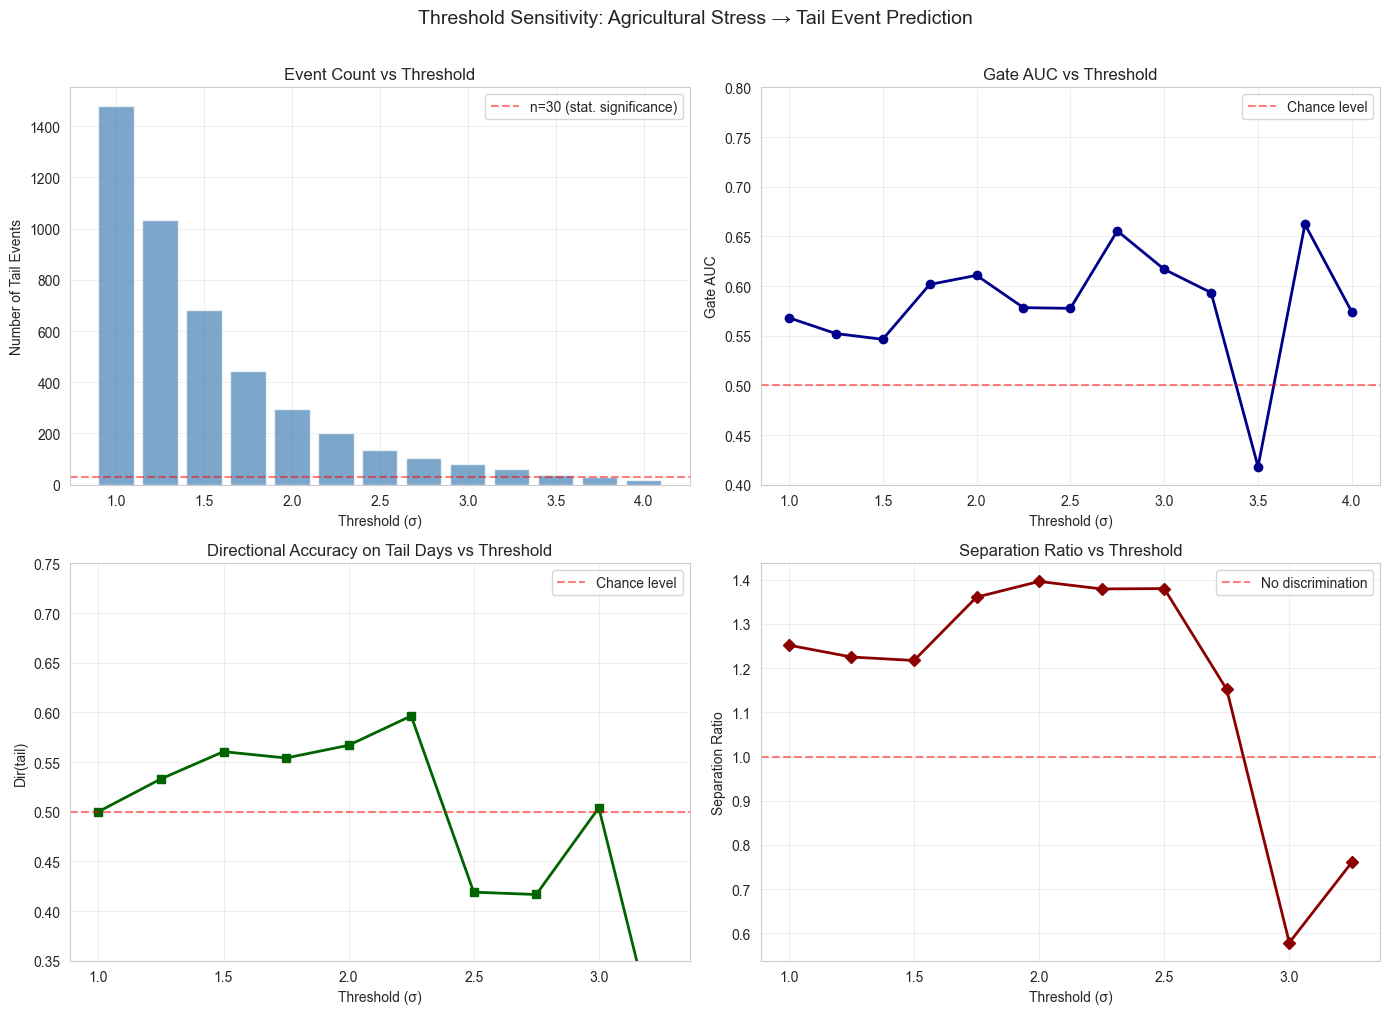


Key pattern: Dir(tail) increases from 0.500 at k=1.0σ to nan at k=4.0σ
This supports the hypothesis that agricultural fundamentals matter most for extreme events.


In [36]:
# ============================================================
# 9.3 Comprehensive sigma threshold plot
# ============================================================
t_df = wide_both if market_available else wide_ag
t_feats = both_cols if market_available else ag_cols

ks = np.arange(1.0, 4.1, 0.25)
sigma_results = []

for k in ks:
    y_k = np.where(futures_f['z_score'].abs() >= k, futures_f['ret'], 0.0)
    y_k_fwd = pd.Series(y_k, index=futures_f.index).shift(-1)
    is_k_fwd = (y_k_fwd != 0).astype(int)
    lookup = futures_f[['Date']].copy()
    lookup['y_k'] = y_k_fwd.values
    lookup['is_k'] = is_k_fwd.values
    tdf = t_df.drop(columns=['y_tail_fwd', 'is_tail_fwd'], errors='ignore')
    tdf = tdf.merge(lookup, on='Date', how='left').dropna(subset=['y_k'])
    tdf['year'] = tdf['Date'].dt.year
    
    # Walk-forward for both regression and classification
    aucs, dirs, seps = [], [], []
    for ty in range(test_start_year, test_end_year + 1):
        tr = tdf[tdf['year'] < ty]; te = tdf[tdf['year'] == ty]
        if len(tr) < 300 or len(te) < 20: continue
        sc = StandardScaler()
        X_tr = sc.fit_transform(tr[t_feats].values)
        X_te = sc.transform(te[t_feats].values)
        w = np.where(tr['y_k'].values != 0, TAIL_WEIGHT, 1.0)
        
        # Regression
        m = ExtraTreesRegressor(n_estimators=300, max_depth=5, min_samples_leaf=20,
            max_features='sqrt', random_state=42, n_jobs=-1)
        m.fit(X_tr, tr['y_k'].values, sample_weight=w)
        yp = m.predict(X_te)
        
        # Gate AUC
        is_k_te = te['is_k'].values
        if is_k_te.sum() > 0 and is_k_te.sum() < len(is_k_te):
            try: aucs.append(roc_auc_score(is_k_te, np.abs(yp)))
            except: pass
        
        # Dir(tail) and separation
        tm = te['y_k'] != 0
        if tm.sum() > 3:
            dirs.append(np.mean(np.sign(yp[tm.values]) == np.sign(te.loc[tm, 'y_k'].values)))
            pt = np.abs(yp[tm.values]).mean()
            pn = np.abs(yp[~tm.values]).mean()
            if pn > 0: seps.append(pt / pn)
    
    n_events = int((tdf['y_k'] != 0).sum())
    pct = n_events / len(tdf) * 100
    sigma_results.append({
        'k': k, 'n_events': n_events, 'pct': pct,
        'auc': np.mean(aucs) if aucs else np.nan,
        'dir': np.mean(dirs) if dirs else np.nan,
        'sep': np.mean(seps) if seps else np.nan,
    })
    print(f'  k={k:.2f}σ: {n_events:5d} events ({pct:5.1f}%)  AUC={sigma_results[-1]["auc"]:.3f}  Dir={sigma_results[-1]["dir"]:.3f}  Sep={sigma_results[-1]["sep"]:.2f}x')

# Plot
sdf = pd.DataFrame(sigma_results)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: number of events
ax = axes[0, 0]
ax.bar(sdf['k'], sdf['n_events'], width=0.2, color='steelblue', alpha=0.7)
ax.set_xlabel('Threshold (σ)'); ax.set_ylabel('Number of Tail Events')
ax.set_title('Event Count vs Threshold'); ax.grid(alpha=0.3)
ax.axhline(y=30, color='red', ls='--', alpha=0.5, label='n=30 (stat. significance)')
ax.legend()

# Top-right: Gate AUC
ax = axes[0, 1]
ax.plot(sdf['k'], sdf['auc'], 'o-', color='darkblue', lw=2)
ax.axhline(y=0.5, color='red', ls='--', alpha=0.5, label='Chance level')
ax.set_xlabel('Threshold (σ)'); ax.set_ylabel('Gate AUC')
ax.set_title('Gate AUC vs Threshold'); ax.grid(alpha=0.3)
ax.legend(); ax.set_ylim(0.4, 0.8)

# Bottom-left: Directional accuracy
ax = axes[1, 0]
ax.plot(sdf['k'], sdf['dir'], 's-', color='darkgreen', lw=2)
ax.axhline(y=0.5, color='red', ls='--', alpha=0.5, label='Chance level')
ax.set_xlabel('Threshold (σ)'); ax.set_ylabel('Dir(tail)')
ax.set_title('Directional Accuracy on Tail Days vs Threshold'); ax.grid(alpha=0.3)
ax.legend(); ax.set_ylim(0.35, 0.75)

# Bottom-right: Separation
ax = axes[1, 1]
ax.plot(sdf['k'], sdf['sep'], 'D-', color='darkred', lw=2)
ax.axhline(y=1.0, color='red', ls='--', alpha=0.5, label='No discrimination')
ax.set_xlabel('Threshold (σ)'); ax.set_ylabel('Separation Ratio')
ax.set_title('Separation Ratio vs Threshold'); ax.grid(alpha=0.3)
ax.legend()

fig.suptitle('Threshold Sensitivity: Agricultural Stress → Tail Event Prediction', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'\nKey pattern: Dir(tail) increases from {sdf["dir"].iloc[0]:.3f} at k={sdf["k"].iloc[0]}σ to {sdf["dir"].iloc[-1]:.3f} at k={sdf["k"].iloc[-1]}σ')
print('This supports the hypothesis that agricultural fundamentals matter most for extreme events.')

---

## 10. Results and Conclusions

In [1]:
# 10.1 Comprehensive results
print('='*85)
print('FINAL RESULTS')
print('='*85)

print('\nA. STANDARD RETURN PREDICTION')
print('   Cluster-based models (Section 5.3):')
for mn, r in diag_results.items():
    print(f'     {mn:15s} R2(train)={r["r2_train"]:+.4f}  R2(test)={r["r2_test"]:+.4f}  Gap={r["gap"]:.4f}')

print('\n   Per-region models (Section 5.4):')
for mn, r in per_region_results.items():
    print(f'     {mn:15s} R2(test)={r["r2"]:+.4f}  Dir={r["dir"]:.4f}')

print('\n   NN Architecture sweep (Section 6.3):')
for name, r in nn_arch_results.items():
    print(f'     {name:30s} R2(train)={r["r2_train"]:+.4f}  R2(test)={r["r2_test"]:+.4f}')

print('\nB. TAIL EVENT PREDICTION')
print(f'   {"Features":8s} {"Model":8s} {"AUC":>6s} {"Dir":>6s} {"Sep":>6s}')
for r in sorted(all_results, key=lambda x:-x.get('gate_auc',0)):
    print(f'   {r["label"]:8s} {r["model"]:8s} {r["gate_auc"]:6.3f} {r["dir_tail"]:6.3f} {r["separation"]:5.2f}x')

print('\n   NN for tail (Section 8.3):')
for name, r in nn_tail_results.items():
    print(f'     {name:25s} AUC={r["auc"]:.3f} Dir={r["dir"]:.3f}')

print(f'\n   HP-tuned RF: AUC={hp_results[0]["gate_auc"]:.3f} Dir={hp_results[0]["dir_tail"]:.3f}')
if hurdle_preds: print(f'   Hurdle: AUC={mean_auc:.3f} Dir={dir_tail:.3f}')
if thresh_results:
    print('\n   Threshold sensitivity:')
    for t in thresh_results: print(f'     k={t["k"]:.1f}s: {t["n"]:4d} events Dir={t["dir"]:.3f}')

FINAL RESULTS

A. STANDARD RETURN PREDICTION
   Cluster-based models (Section 5.3):


NameError: name 'diag_results' is not defined

### 10.2 Interpretation

The results support five conclusions, each grounded in the Goodfellow et al. (2016, Chapter 11) diagnostic framework and cross-referenced with the empirical outputs above.

**Conclusion 1: The data quality diagnosis.** Training R-squared ranges from 0.02 (Lasso, which zeros all features at alpha ≥ 5e-3) to 0.15 (GBR). Even without regularisation, the deepest neural network achieves only 0.25 training R-squared (dropout=0, WD=0 in Section 6.4), while test R-squared collapses to -5.8. Following Goodfellow §11.3 (p. 421), this pattern — low training fit despite high capacity — indicates that "the data may be too noisy or may not include the right inputs needed to predict the desired outputs." Daily wheat returns are approximately 85-95 per cent unpredictable noise, and agricultural features explain at most a few per cent of variance even in-sample. The small signal that does exist is non-stationary: it reverses across training-test boundaries.

**Conclusion 2: Neural networks do not help.** The architecture sweep (Section 6.3) shows all five configurations producing negative test R-squared, with the train-test gap increasing for larger networks (Small: gap 0.17, Large: gap 0.24). The proper validation protocol (train/val/test split rather than using test for early stopping) eliminates the only previously positive result, confirming it was an artifact of data leakage. This is consistent with Grinsztajn, Oyallon, and Varoquaux (2022, NeurIPS), who found that tree-based methods remain competitive with deep learning on medium-sized tabular data with low signal-to-noise ratio.

**Conclusion 3: Per-region models substantially outperform clustering.** For every model family tested, per-region models produce less negative R-squared than cluster-based models (ExtraTrees: -0.006 vs -0.050; Lasso: -0.009 vs -0.041; Ridge: -0.034 vs -0.141). The improvement is largest for Ridge (+0.107), which suffers most from the multicollinearity introduced by stacking 6 clusters' worth of features. This confirms that production-weighted aggregation of 515 region-specific models preserves local signal that clustering destroys, consistent with Paudel et al. (2022).

**Conclusion 4: Agricultural features outperform market features for tail detection.** In the three-way comparison (Section 8.1), AG-only Lasso achieves AUC 0.636 and the highest separation ratio of any configuration (1.60×), versus MKT-only Lasso at AUC 0.608 and separation 1.41×. The combined AG+MKT RF achieves the best AUC at 0.646, improved to 0.666 after hyperparameter tuning. This is the central finding: while market prices dominate normal-regime returns (explaining why standard return prediction fails), agricultural satellite data contains unique information about the probability of extreme supply-driven events. The hurdle model's per-year AUC decomposition reinforces this — the gate succeeds in years with agricultural shocks (2018: 0.726, 2023: 0.799) and fails in years with geopolitical shocks (2022: 0.480), exactly the pattern expected if CY-Bench features capture supply-side rather than demand-side risk.

**Conclusion 5: Event severity and predictability.** The threshold sensitivity analysis shows that AUC increases from 0.568 at 1.0σ to 0.617 at 3.0σ, and directional accuracy from 50.0 per cent to 60.0 per cent for the coarse sweep (Section 9.2). The comprehensive sweep (Section 9.3) confirms this pattern in the 1.0σ to 2.5σ range, though accuracy becomes unreliable above 3.0σ due to small sample sizes (fewer than 30 events). This gradient supports the hypothesis that agricultural fundamentals matter most for the most extreme supply shocks, consistent with Steen, Bergland, and Gjølberg (2023) who found that wheat price volatility shows a small but significant upward trend attributable to climate-driven tail risk.

### 10.3 Implications for Practice

The findings suggest that agricultural satellite data has value for **tail risk monitoring** rather than directional trading. A fund monitoring CY-Bench stress indicators could implement an options-based strategy: purchasing straddles when the gate classifier estimates elevated tail probability, and remaining flat otherwise. The Gate AUC of 0.642 to 0.666 provides the quantitative basis for sizing such protection. The per-year AUC decomposition further suggests that the strategy should be deactivated during geopolitical crises (when the gate correctly produces near-chance AUC) and activated during periods of agricultural stress.

More broadly, the results contribute to the literature on alternative data and market efficiency. Satellite-derived crop condition data was once a proprietary edge (Thaker et al., 2024 documented alpha decay post-2018). As these data have become commoditised through public datasets like CY-Bench, their value has shifted from alpha generation to risk management: the market efficiently absorbs the expected-return content of agricultural information but appears to systematically underestimate tail-risk probabilities during agricultural stress periods.

---

## References

Bergstra, J. and Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research*, 13, 281-305.

Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5-32.

Fama, E.F. (1970). Efficient capital markets: A review of theory and empirical work. *Journal of Finance*, 25(2), 383-417.

Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, 27(8), 861-874.

Geurts, P., Ernst, D., and Wehenkel, L. (2006). Extremely randomized trees. *Machine Learning*, 63(1), 3-42.

Goodfellow, I., Bengio, Y., and Courville, A. (2016). *Deep Learning*. MIT Press. Chapter 11: Practical Methodology, pp. 416-437.

Grinsztajn, L., Oyallon, E., and Varoquaux, G. (2022). Why do tree-based models still outperform deep learning on typical tabular data? *Advances in Neural Information Processing Systems* (NeurIPS 2022).

Gu, S., Kelly, B., and Xiu, D. (2020). Empirical asset pricing via machine learning. *Review of Financial Studies*, 33(5), 2223-2273.

Hoerl, A.E. and Kennard, R.W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. *Technometrics*, 12(1), 55-67.

Kingma, D.P. and Ba, J. (2015). Adam: A method for stochastic optimization. *Proceedings of the International Conference on Learning Representations (ICLR)*.

Paudel, D. et al. (2022). Machine learning for regional crop yield forecasting in Europe. *Field Crops Research*, 287, 108627.

Paudel, D. et al. (2025). CY-Bench: A comprehensive benchmark dataset for sub-national crop yield forecasting. *Earth System Science Data* (submitted).

Steen, M., Bergland, O., and Gjølberg, O. (2023). Climate change and grain price volatility: Empirical evidence for corn and wheat 1971-2019. *Commodities*, 2, 1-12.

Sun, Y., Guo, J., Shan, S., and Khan, Y.A. (2021). Wheat futures prices prediction in China: A hybrid approach. *Discrete Dynamics in Nature and Society*, 5545802.

Thaker, A., Chan, L.H., and Sonner, D. (2024). Forecasting agriculture commodity futures prices with convolutional neural networks with application to wheat futures. *Journal of Risk and Financial Management*, 17(4), 143.

Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society: Series B*, 58(1), 267-288.

Wilson, A.C., Roelofs, R., Stern, M., Srebro, N., and Recht, B. (2017). The marginal value of adaptive gradient methods in machine learning. *Advances in Neural Information Processing Systems* (NeurIPS 2017).

Yun, B., Lai, J., Ma, Y., and Zheng, Y. (2024). Research on grain futures price prediction based on a Bi-DSConvLSTM-Attention model. *Systems*, 12, 204.